Processing 1978 - No wind farms...
Processing 1978 - Current wind farms...
Processing 1978 - Future wind farms...
Processing 2073 - No wind farms...
Processing 2073 - Current wind farms...
Processing 2073 - Future wind farms...


/tmp/ipykernel_4031604/134693683.py:118: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  current_cmap = cm.get_cmap('viridis')


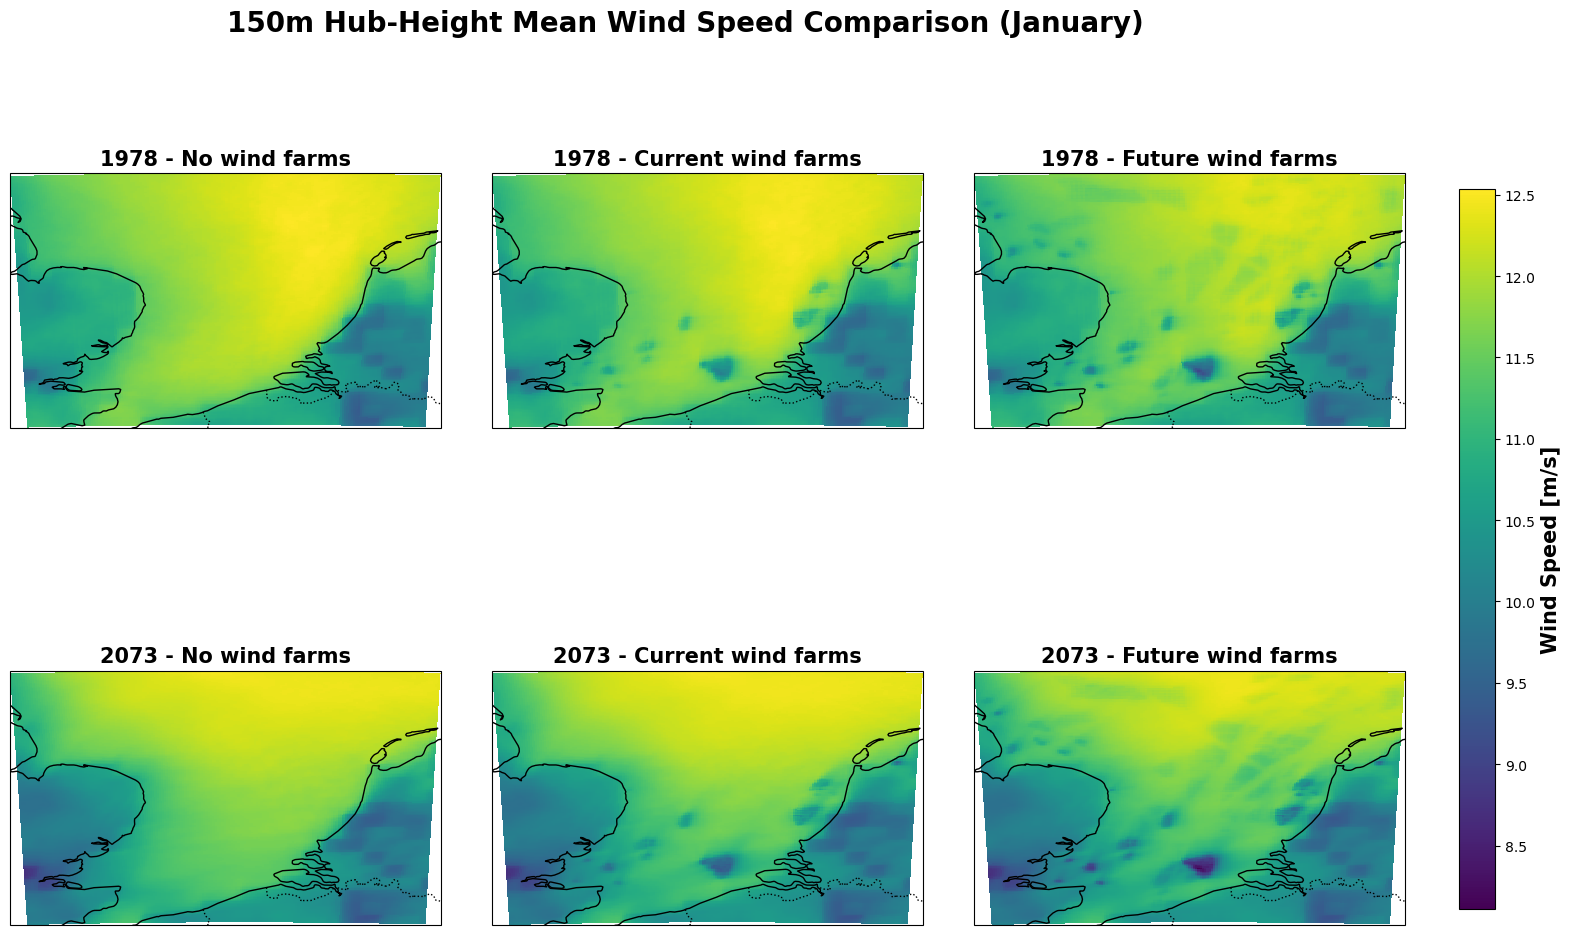

In [3]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm          
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np
from scipy.interpolate import NearestNDInterpolator  # Added for filling NaN holes

# --- 1. Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No wind farms'),
    ('exp1994_WF', '1978 - Current wind farms'),
    ('exp1994_WFF', '1978 - Future wind farms'),
    ('experiment2', '2073 - No wind farms'),
    ('exp2071_WF', '2073 - Current wind farms'),
    ('exp2071_WFF', '2073 - Future wind farms')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0  

def fill_nan_with_nearest(data, lats, lons):
    """Fills NaN holes in the 2D grid using the nearest valid neighbor's value."""
    if not np.isnan(data).any():
        return data  # No holes to fill
        
    # Find coordinates where data is valid and where it is NaN
    valid_mask = ~np.isnan(data)
    nan_mask = np.isnan(data)
    
    # Extract the (lon, lat) positions for valid points and NaN points
    valid_coords = np.column_stack((lons[valid_mask], lats[valid_mask]))
    nan_coords = np.column_stack((lons[nan_mask], lats[nan_mask]))
    
    # Create the nearest neighbor interpolator using only valid data
    interpolator = NearestNDInterpolator(valid_coords, data[valid_mask])
    
    # Fill the NaNs and return the patched array
    filled_data = data.copy()
    filled_data[nan_mask] = interpolator(nan_coords)
    return filled_data

def get_mean_150m_wind(exp_folder):
    """Calculates mean 150m wind speed for a specific experiment folder."""
    all_august_files = sorted(glob.glob(f"{base_path}{exp_folder}/{file_pattern}"))
    
    files = []
    for f in all_august_files:
        match = re.search(r'-01-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 30:
                files.append(f)
                
    if not files:
        print(f"   [Warning] No matching files found for days 01-30 of Jan. for {exp_folder}")
        return None, None, None

    running_sum = None
    count = 0
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", units="m s-1", timeidx=None) 
        v = getvar(nc, "va", units="m s-1", timeidx=None)
        height = getvar(nc, "height_agl", units="m", timeidx=None)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, TARGET_HEIGHT)
        
        wspd_values = wspd_150m.values
        if wspd_values.ndim == 3:  
            hours_in_file = wspd_values.shape[0]
            wspd_sum = np.sum(wspd_values, axis=0)
        else:
            hours_in_file = 1
            wspd_sum = wspd_values
            
        if running_sum is None:
            running_sum = wspd_sum
            lats = to_np(wspd_150m.coords["XLAT"])
            lons = to_np(wspd_150m.coords["XLONG"])
            if lats.ndim == 3: lats = lats[0, :, :]
            if lons.ndim == 3: lons = lons[0, :, :]
        else:
            running_sum += wspd_sum
            
        nc.close()
        count += hours_in_file
        
    return running_sum / count, lats, lons

# --- 2. Process Data ---
results = {}
lats, lons = None, None

for folder, title in experiments:
    print(f"Processing {title}...")
    mean_val, x_lats, x_lons = get_mean_150m_wind(folder)
    
    # Spatial fix: patch the NaN holes right after extraction using coordinates
    if mean_val is not None:
        mean_val = fill_nan_with_nearest(mean_val, x_lats, x_lons)
        
    results[folder] = mean_val
    if x_lats is not None:
        lats, lons = x_lats, x_lons

# --- 3. Determine Global Limits ---
all_values = [v for v in results.values() if v is not None]
vmin = min(np.nanmin(v) for v in all_values)
vmax = max(np.nanmax(v) for v in all_values)

# Grab clean colormap (REMOVED .set_bad() since holes are filled natively)
current_cmap = cm.get_cmap('viridis')

# --- 4. Plotting 6 Panels ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

mesh = None 

for i, (folder, title) in enumerate(experiments):
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    data = results[folder]
    
    if data is not None:
        mesh = ax.pcolormesh(lons, lats, data, 
                             transform=ccrs.PlateCarree(), 
                             cmap=current_cmap, 
                             vmin=vmin, vmax=vmax,
                             shading='nearest')
    
    ax.set_title(title, fontsize=15, fontweight='bold')

if mesh is not None:
    cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='vertical')
    cbar.set_label('Wind Speed [m/s]', fontsize=15, fontweight='bold')

plt.suptitle('150m Hub-Height Mean Wind Speed Comparison (January)', fontsize=20, fontweight='bold', y=0.95)
plt.subplots_adjust(bottom=0.12, top=0.88, wspace=0.12, hspace=0.2)

plt.savefig(f"{base_path}wind_speed_150m_absolute_map.png", dpi=300, bbox_inches='tight')
plt.show()

Extracting MABL Diagnostics for: 1978 - no WF (31 files matched)...
Extracting MABL Diagnostics for: 1978 - Current WF (31 files matched)...
Extracting MABL Diagnostics for: 1978 - Future WF (31 files matched)...
Extracting MABL Diagnostics for: 2073 - no WF (31 files matched)...
Extracting MABL Diagnostics for: 2073 - Current WF (31 files matched)...
Extracting MABL Diagnostics for: 2073 - Future WF (31 files matched)...


/tmp/ipykernel_2894651/3731349572.py:221: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
/tmp/ipykernel_2894651/3731349572.py:222: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
/tmp/ipykernel_2894651/3731349572.py:224: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')
/tmp/ipykernel_2894651/3731349572.py:225: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')


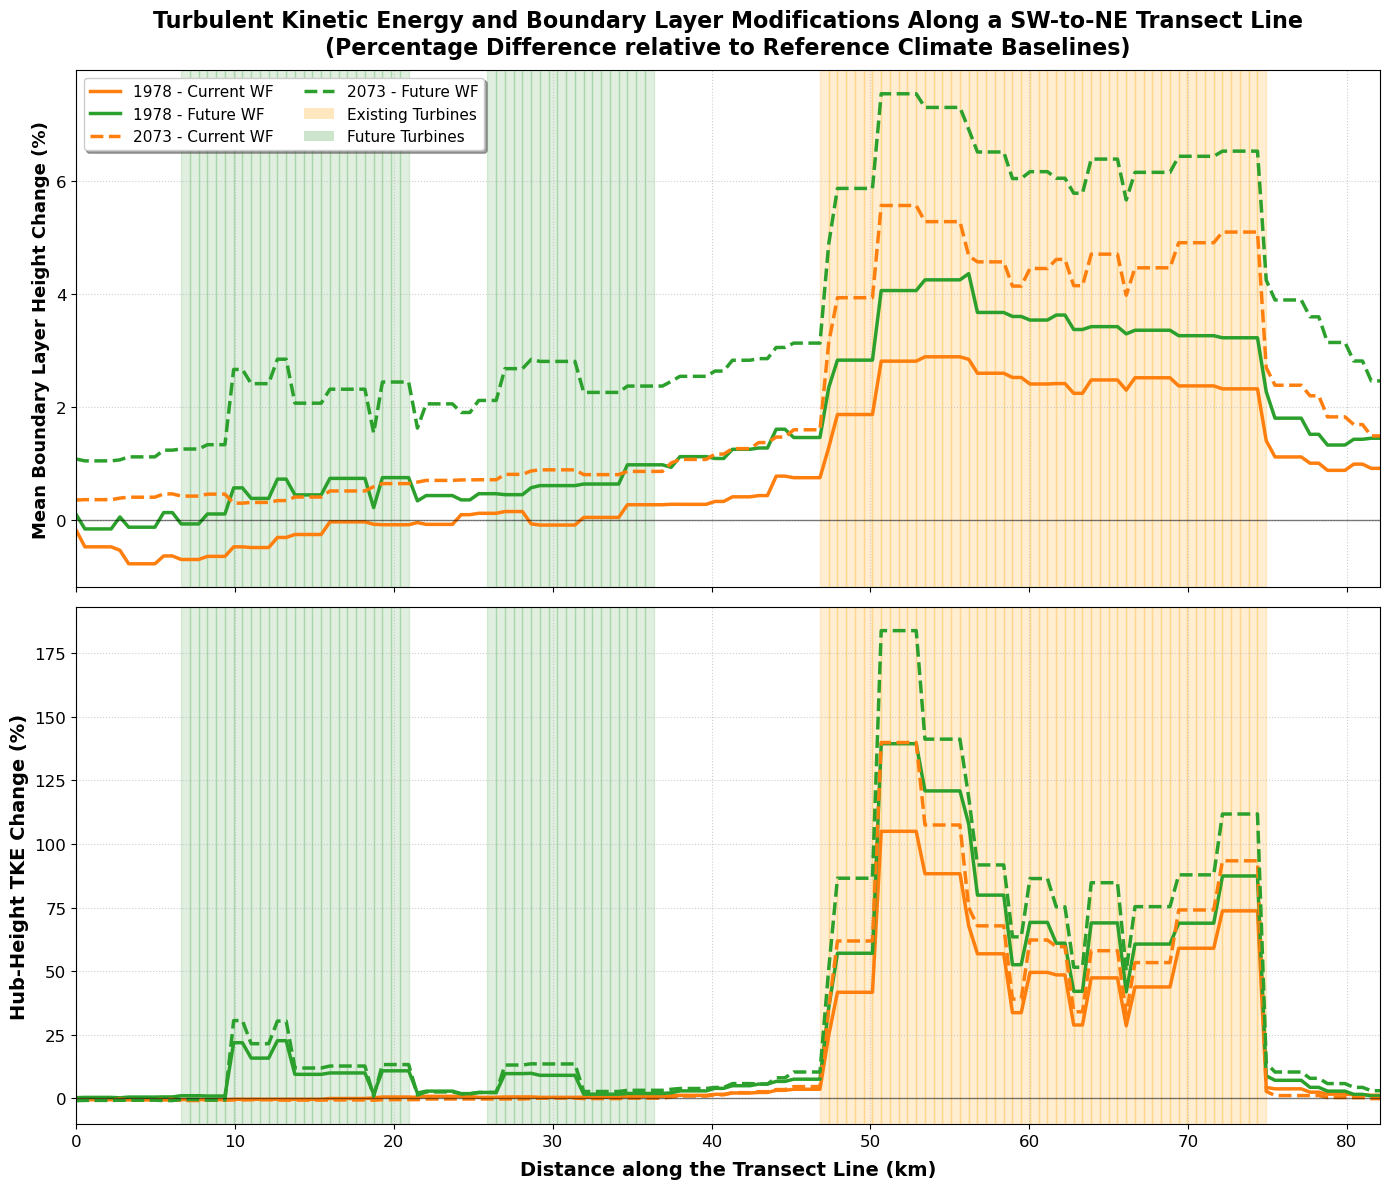

In [7]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing MABL NetCDF Diagnostics ---
pblh_profiles = {}
tke_profiles = {}

for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    
    files = []
    for f in all_august_files:
        match = re.search(r'-01-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 31:
                files.append(f)
                
    if not files: 
        continue
        
    print(f"Extracting MABL Diagnostics for: {label} ({len(files)} files matched)...")
    
    sum_pblh = None
    sum_tke_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        
        pblh_hourly = getvar(nc, "PBLH", timeidx=None) 
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        tke_3d = None
        try:
            tke_3d = getvar(nc, "tke", timeidx=None, units="m2 s-2")
        except (KeyError, ValueError):
            pass
            
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "qke", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass
                
        if tke_3d is None:
            try:
                tke_3d = getvar(nc, "QKE", timeidx=None) * 0.5
            except (KeyError, ValueError):
                pass

        if tke_3d is None:
            tke_3d = height * 0.0 
        
        tke_150m = interplevel(tke_3d, height, TARGET_HEIGHT)
        
        hours_in_file = pblh_hourly.shape[0] if pblh_hourly.ndim == 3 else 1
        pblh_sum = np.sum(pblh_hourly.values, axis=0) if pblh_hourly.ndim == 3 else pblh_hourly.values
        tke_sum = np.sum(tke_150m.values, axis=0) if tke_150m.ndim == 3 else tke_150m.values
        
        if sum_pblh is None:
            sum_pblh = pblh_sum
            sum_tke_150m = tke_sum
        else:
            sum_pblh += pblh_sum
            sum_tke_150m += tke_sum
            
        total_hours += hours_in_file
        nc.close()
        
    if sum_pblh is None or total_hours == 0:
        continue
        
    mean_pblh_grid = sum_pblh / total_hours
    mean_tke_grid = sum_tke_150m / total_hours
    
    # FIXED INDEXING BUG: Indexed as mean_grid[y, x] matching array rows/cols
    pblh_profiles[folder] = np.array([mean_pblh_grid[y, x] for x, y in zip(x_indices, y_indices)])
    tke_profiles[folder] = np.array([mean_tke_grid[y, x] for x, y in zip(x_indices, y_indices)])

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

pblh_ref_1994 = pblh_profiles['exp1994']
pblh_ref_2071 = pblh_profiles['experiment2']

tke_ref_1994 = tke_profiles['exp1994']
tke_ref_2071 = tke_profiles['experiment2']

line_handles = []

for folder, label, color, linestyle in experiments:
    # Skip plotting control baselines directly
    if folder in ['exp1994', 'experiment2']:
        continue
        
    if '1994' in folder:
        pblh_ref = pblh_ref_1994
        tke_ref = tke_ref_1994
        plot_label = f"{label}"
    else:
        pblh_ref = pblh_ref_2071
        tke_ref = tke_ref_2071
        plot_label = f"{label}"
        
    # Calculate % Differences safely
    pblh_diff = np.where(pblh_ref > 0, ((pblh_profiles[folder] - pblh_ref) / pblh_ref) * 100, 0)
    tke_diff  = np.where(tke_ref > 0,  ((tke_profiles[folder] - tke_ref) / tke_ref) * 100, 0)
    
    # Top Panel: PBLH Percentage Difference
    line, = ax1.plot(distances_km, pblh_diff, label=plot_label, color=color, linestyle=linestyle, linewidth=2.5)
    line_handles.append(line)
    
    # Bottom Panel: TKE Percentage Difference
    ax2.plot(distances_km, tke_diff, label=plot_label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.12, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.18, edgecolor='none')

# --- 8. Create Combined Custom Legend ---
# Shading Zone Legend Handles
zone_patches = [
    Patch(facecolor='orange', alpha=0.25, edgecolor='none', label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.20, edgecolor='none', label='Future Turbines')
]

# Combine experiment lines + shading patches into one legend frame
all_handles = line_handles + zone_patches

# Style Top Panel (PBLH)
ax1.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax1.set_ylabel("Mean Boundary Layer Height Change (%)", fontsize=13, fontweight='bold')
ax1.set_title("Turbulent Kinetic Energy and Boundary Layer Modifications Along a SW-to-NE Transect Line\n(Percentage Difference relative to Reference Climate Baselines)", fontsize=16, fontweight='bold', pad=12)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(handles=all_handles, loc='upper left', fontsize=11, frameon=True, ncol=2, shadow=True)

# Style Bottom Panel (TKE)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)
ax2.set_ylabel("Hub-Height TKE Change (%)", fontsize=14, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

for ax in [ax1, ax2]:
    ax.set_xlim(0, max(distances_km))
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f"{base_path}mabl_stability_percentage_diagnostics.png", dpi=300)
plt.show()

Processing 1978 - No wind farms...
Processing 1978 - Current wind farms...
Processing 1978 - Future wind farms...
Processing 2073 - No wind farms...
Processing 2073 - Current wind farms...
Processing 2073 - Future wind farms...


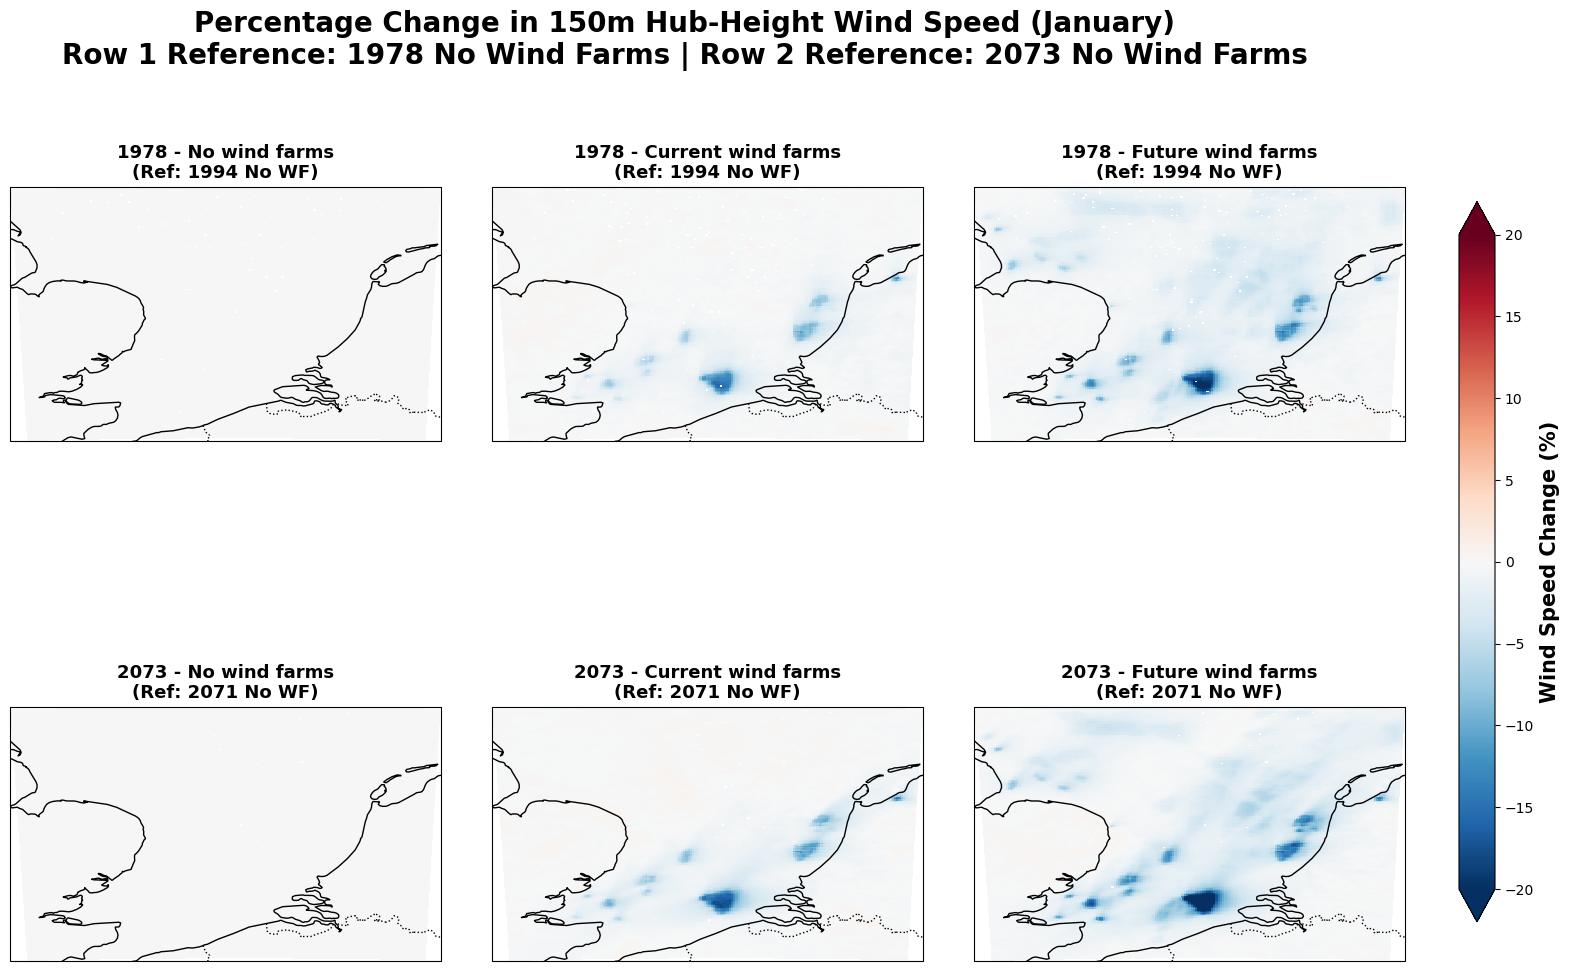

In [ ]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np

# --- 1. Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No wind farms'),
    ('exp1994_WF', '1978 - Current wind farms'),
    ('exp1994_WFF', '1978 - Future wind farms'),
    ('experiment2', '2073 - No wind farms'),
    ('exp2071_WF', '2073 - Current wind farms'),
    ('exp2071_WFF', '2073 - Future wind farms')
]

# Define both reference keys explicitly
ref_1994_key = 'exp1994'
ref_2071_key = 'experiment2'

# STRICT GLOB: Isolates August files completely to avoid January contamination
file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0  # Swapped from 100m to 150m Hub Height
plot_limit = 20  # Fixed limit for percentage (%)

def get_mean_150m_wind(exp_folder):
    """Calculates mean 150m wind speed for a specific experiment folder."""
    all_august_files = sorted(glob.glob(f"{base_path}{exp_folder}/{file_pattern}"))
    
    # Safe regex filtering ensuring only days 01 to 30 of August are read
    files = []
    for f in all_august_files:
        match = re.search(r'-01-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 30:
                files.append(f)
                
    if not files:
        print(f"   [Warning] No matching files found for days 01-30 of August for {exp_folder}")
        return None, None, None

    running_sum = None
    count = 0
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", units="m s-1", timeidx=None) 
        v = getvar(nc, "va", units="m s-1", timeidx=None)
        height = getvar(nc, "height_agl", units="m", timeidx=None)
        
        # Calculate instantaneous magnitude vector
        wspd = np.sqrt(u**2 + v**2)
        
        # Interpolate down to 150 meters
        wspd_150m = interplevel(wspd, height, TARGET_HEIGHT)
        
        # Check if file has multiple time steps or is a single frame
        wspd_values = wspd_150m.values
        if wspd_values.ndim == 3:  # (Time, South_North, West_East)
            hours_in_file = wspd_values.shape[0]
            wspd_sum = np.sum(wspd_values, axis=0)
        else:
            hours_in_file = 1
            wspd_sum = wspd_values
            
        if running_sum is None:
            running_sum = wspd_sum
            # Extract spatial coordinates safely using wrf-python native properties
            lats = to_np(wspd_150m.coords["XLAT"])
            lons = to_np(wspd_150m.coords["XLONG"])
            # If coordinates contain a time dimension, drop it to match 2D layout mesh
            if lats.ndim == 3: lats = lats[0, :, :]
            if lons.ndim == 3: lons = lons[0, :, :]
        else:
            running_sum += wspd_sum
            
        nc.close()
        count += hours_in_file
        
    return running_sum / count, lats, lons

# --- 2. Process Data ---
results = {}

# Process all experiments and store them in the results dictionary
for folder, title in experiments:
    print(f"Processing {title}...")
    mean_val, lat_coords, lon_coords = get_mean_150m_wind(folder)
    results[folder] = mean_val
    # Keep updating lats/lons to ensure we have valid grids for plotting
    if lat_coords is not None:
        lats, lons = lat_coords, lon_coords

# Assign references from the results dictionary
ref_1994 = results[ref_1994_key]
ref_2071 = results[ref_2071_key]

# --- 3. Plotting 6 Panels ---
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (folder, title) in enumerate(experiments):
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Select reference based on row index (i < 3 is Row 1, i >= 3 is Row 2)
    if i < 3:
        current_ref = ref_1994
        ref_label = "Ref: 1978 No WF"
    else:
        current_ref = ref_2071
        ref_label = "Ref: 2073 No WF"
    
    # Calculate Percentage Difference relative to the dynamically selected reference
    diff_pct = ((results[folder] - current_ref) / current_ref) * 100
    
    mesh = ax.pcolormesh(lons, lats, diff_pct, 
                         transform=ccrs.PlateCarree(), 
                         cmap='RdBu_r', 
                         vmin=-plot_limit, vmax=plot_limit)
    
    # Added the specific reference explicitly to each subplot title for clarity
    ax.set_title(f"{title}\n({ref_label})", fontsize=13, fontweight='bold')

# Shared vertical colorbar on the right flank
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', extend='both')
cbar.set_label('Wind Speed Change (%)', fontsize=15, fontweight='bold')

# Updated the overarching title to match the new split-reference strategy
plt.suptitle('Percentage Change in 150m Hub-Height Wind Speed (January)\n'
             'Row 1 Reference: 1978 No Wind Farms | Row 2 Reference: 2073 No Wind Farms', 
             fontsize=20, fontweight='bold', y=0.96)
plt.subplots_adjust(bottom=0.10, top=0.88, wspace=0.12, hspace=0.25)

# Ensure save matches your standard path block layout output
plt.savefig(f"{base_path}wind_speed_150m_percentage_change_split_ref_map.png", dpi=300, bbox_inches='tight')
plt.show()

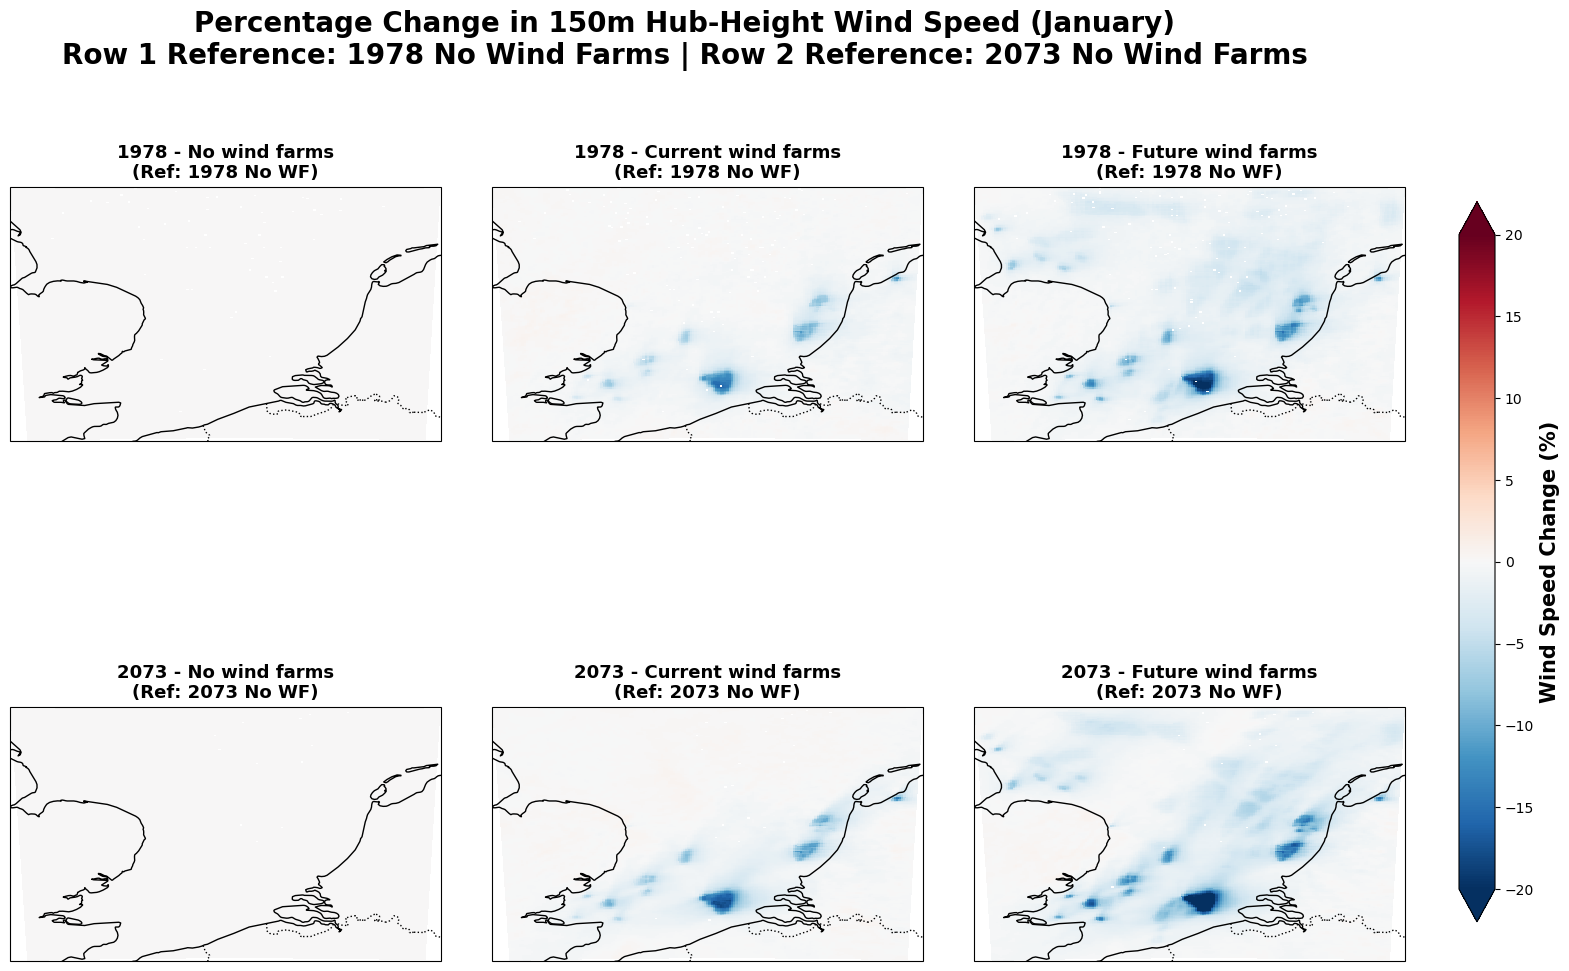

In [3]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (folder, title) in enumerate(experiments):
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Select reference based on row index (i < 3 is Row 1, i >= 3 is Row 2)
    if i < 3:
        current_ref = ref_1994
        ref_label = "Ref: 1978 No WF"
    else:
        current_ref = ref_2071
        ref_label = "Ref: 2073 No WF"
    
    # Calculate Percentage Difference relative to the dynamically selected reference
    diff_pct = ((results[folder] - current_ref) / current_ref) * 100
    
    mesh = ax.pcolormesh(lons, lats, diff_pct, 
                         transform=ccrs.PlateCarree(), 
                         cmap='RdBu_r', 
                         vmin=-plot_limit, vmax=plot_limit)
    
    # Added the specific reference explicitly to each subplot title for clarity
    ax.set_title(f"{title}\n({ref_label})", fontsize=13, fontweight='bold')

# Shared vertical colorbar on the right flank
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', extend='both')
cbar.set_label('Wind Speed Change (%)', fontsize=15, fontweight='bold')

# Updated the overarching title to match the new split-reference strategy
plt.suptitle('Percentage Change in 150m Hub-Height Wind Speed (January)\n'
             'Row 1 Reference: 1978 No Wind Farms | Row 2 Reference: 2073 No Wind Farms', 
             fontsize=20, fontweight='bold', y=0.96)
plt.subplots_adjust(bottom=0.10, top=0.88, wspace=0.12, hspace=0.25)

# Ensure save matches your standard path block layout output
plt.savefig(f"{base_path}wind_speed_150m_percentage_change_split_ref_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import getvar, interplevel, to_np

# --- 1. Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No wind farms'),
    ('exp1994_WF', '1978 - Current wind farms'),
    ('exp1994_WFF', '1978 - Future wind farms'),
    ('experiment2', '2073 - No wind farms'),
    ('exp2071_WF', '2073 - Current wind farms'),
    ('exp2071_WFF', '2073 - Future wind farms')
]

# Define both reference keys explicitly
ref_1994_key = 'exp1994'
ref_2071_key = 'experiment2'

# STRICT GLOB: Isolates August files completely 
file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0  # Swapped from 100m to 150m Hub Height
plot_limit = 20  # Fixed limit for percentage (%)

def get_mean_150m_wind(exp_folder):
    """Calculates mean 150m wind speed for a specific experiment folder."""
    all_august_files = sorted(glob.glob(f"{base_path}{exp_folder}/{file_pattern}"))
    
    # Safe regex filtering ensuring only days 01 to 31 of 
    files = []
    for f in all_august_files:
        match = re.search(r'-01-(\d{2})', f)
        if match:
            day_val = int(match.group(1))
            if day_val <= 31:
                files.append(f)
                
    if not files:
        print(f"   [Warning] No matching files found for days 01-30 of August for {exp_folder}")
        return None, None, None

    running_sum = None
    count = 0
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", units="m s-1", timeidx=None) 
        v = getvar(nc, "va", units="m s-1", timeidx=None)
        height = getvar(nc, "height_agl", units="m", timeidx=None)
        
        # Calculate instantaneous magnitude vector
        wspd = np.sqrt(u**2 + v**2)
        
        # Interpolate down to 150 meters
        wspd_150m = interplevel(wspd, height, TARGET_HEIGHT)
        
        # Check if file has multiple time steps or is a single frame
        wspd_values = wspd_150m.values
        if wspd_values.ndim == 3:  # (Time, South_North, West_East)
            hours_in_file = wspd_values.shape[0]
            wspd_sum = np.sum(wspd_values, axis=0)
        else:
            hours_in_file = 1
            wspd_sum = wspd_values
            
        if running_sum is None:
            running_sum = wspd_sum
            # Extract spatial coordinates safely using wrf-python native properties
            lats = to_np(wspd_150m.coords["XLAT"])
            lons = to_np(wspd_150m.coords["XLONG"])
            # If coordinates contain a time dimension, drop it to match 2D layout mesh
            if lats.ndim == 3: lats = lats[0, :, :]
            if lons.ndim == 3: lons = lons[0, :, :]
        else:
            running_sum += wspd_sum
            
        nc.close()
        count += hours_in_file
        
    return running_sum / count, lats, lons

# --- 2. Process Data ---
results = {}

# Process all experiments and store them in the results dictionary
for folder, title in experiments:
    print(f"Processing {title}...")
    mean_val, lat_coords, lon_coords = get_mean_150m_wind(folder)
    results[folder] = mean_val
    # Keep updating lats/lons to ensure we have valid grids for plotting
    if lat_coords is not None:
        lats, lons = lat_coords, lon_coords

# Assign references from the results dictionary
ref_1994 = results[ref_1994_key]
ref_2071 = results[ref_2071_key]

# --- 3. Plotting 6 Panels ---

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (folder, title) in enumerate(experiments):
    ax = axes[i]
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    # Select reference based on row index (i < 3 is Row 1, i >= 3 is Row 2)
    if i < 3:
        current_ref = ref_1994
        ref_label = "Ref: 1978 No WF"
    else:
        current_ref = ref_2071
        ref_label = "Ref: 2073 No WF"
    
    # Calculate Percentage Difference relative to the dynamically selected reference
    diff_pct = ((results[folder] - current_ref) / current_ref) * 100
    
    mesh = ax.pcolormesh(lons, lats, diff_pct, 
                         transform=ccrs.PlateCarree(), 
                         cmap='RdBu_r', 
                         vmin=-plot_limit, vmax=plot_limit)
    
    # Added the specific reference explicitly to each subplot title for clarity
    ax.set_title(f"{title}\n({ref_label})", fontsize=13, fontweight='bold')

# Shared vertical colorbar on the right flank
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='vertical', extend='both')
cbar.set_label('Wind Speed Change (%)', fontsize=15, fontweight='bold')

# Updated the overarching title to match the new split-reference strategy
plt.suptitle('Percentage Change in 150m Hub-Height Wind Speed (January)\n'
             'Row 1 Reference: 1978 No Wind Farms | Row 2 Reference: 2073 No Wind Farms', 
             fontsize=20, fontweight='bold', y=0.96)
plt.subplots_adjust(bottom=0.10, top=0.88, wspace=0.12, hspace=0.25)

# Ensure save matches your standard path block layout output
plt.savefig(f"{base_path}wind_speed_150m_percentage_change_split_ref_map.png", dpi=300, bbox_inches='tight')
plt.show()

Stratifying data for: 1978 - No WF...
 -> 1978 - No WF: Stable Hours = 0, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 15, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 39, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 40, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 64, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 78, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 99, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 123, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 147, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 157, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 157, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 168, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 168, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 185, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 188, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 207, Unstable Hours = 0
 -> 1978 - No WF: Stable Hours = 231, Unstable Hours = 0
 

/tmp/ipykernel_1416168/156432847.py:241: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_1416168/156432847.py:242: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_1416168/156432847.py:244: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_1416168/156432847.py:245: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


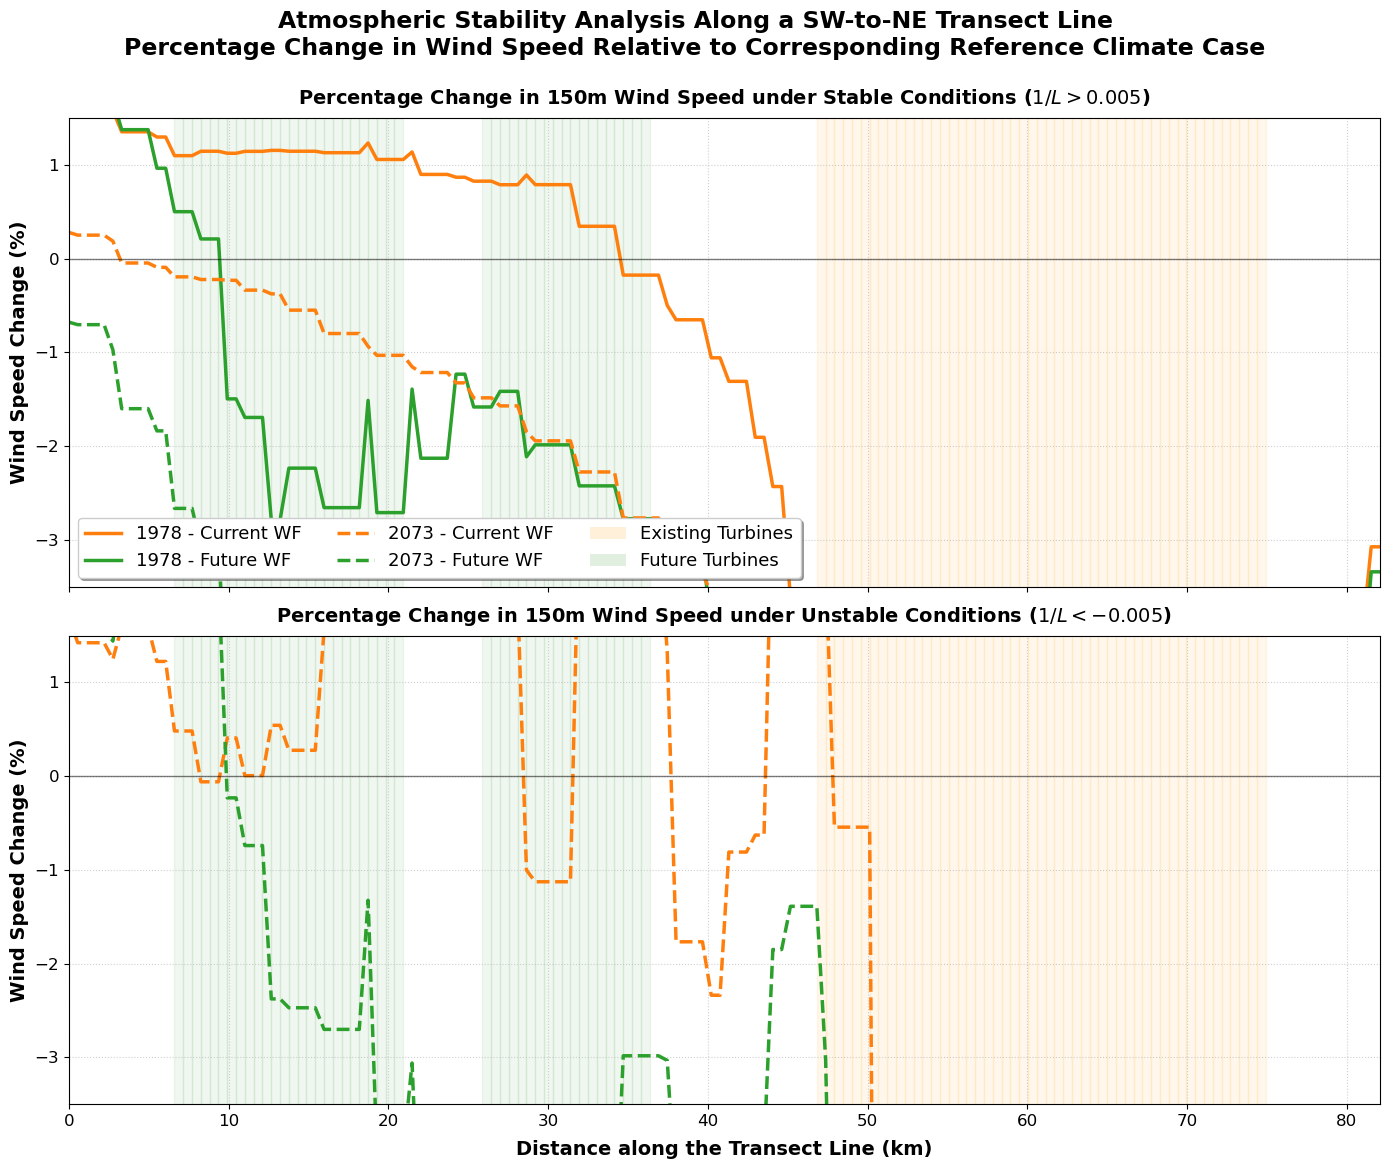

In [16]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - No WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Hourly Processing & Stability Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# Dictionaries to hold separate stability profiles
stable_profiles = {}
unstable_profiles = {}

for folder, label, color, linestyle in experiments:
    all_august_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in all_august_files if int(f.split('_')[-2].split('-')[-1]) <= 30]
    if not files: 
        continue
    
    print(f"Stratifying data for: {label}...")
    
    stable_wspd_sum = np.zeros(NUM_POINTS)
    unstable_wspd_sum = np.zeros(NUM_POINTS)
    stable_hours = 0
    unstable_hours = 0
    
    for f in files:
        print(f" -> {label}: Stable Hours = {stable_hours}, Unstable Hours = {unstable_hours}")
        nc = Dataset(f)
        
        # Pull 3D Wind parameters and interpolate to Hub Height (150m)
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        wspd_3d = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT).values
        
        # Pull Surface Variables for Hourly Stability Assessment
        ust = getvar(nc, "UST", timeidx=None).values
        hfx = getvar(nc, "HFX", timeidx=None).values
        th2 = getvar(nc, "TH2", timeidx=None).values
        
        num_times = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        
        for t in range(num_times):
            # Extract 2D slices for this specific hour
            wspd_t = wspd_150m[t, :, :] if num_times > 1 else wspd_150m
            ust_t = ust[t, :, :] if num_times > 1 else ust
            hfx_t = hfx[t, :, :] if num_times > 1 else hfx
            th2_t = th2[t, :, :] if num_times > 1 else th2
            
            # Calculate 2D Inverse Obukhov Length (1/L) for this hour
            hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
            inv_L = (kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
            
            # Extract values along the transect line for this specific hour
            transect_wspd = np.array([wspd_t[y, x] for x, y in zip(x_indices, y_indices)])
            transect_inv_L = np.array([inv_L[y, x] for x, y in zip(x_indices, y_indices)])
            
            # Classify the mean stability state of the transect corridor for this hour
            mean_corridor_inv_L = np.mean(transect_inv_L)
            
            if mean_corridor_inv_L > 0.005:  # Stable conditions regime
                stable_wspd_sum += transect_wspd
                stable_hours += 1
            elif mean_corridor_inv_L < -0.005:  # Unstable conditions regime
                unstable_wspd_sum += transect_wspd
                unstable_hours += 1
                
        nc.close()
        
    # Calculate averages only if hours matched the regime bins
    if stable_hours > 0:
        stable_profiles[folder] = stable_wspd_sum / stable_hours
    if unstable_hours > 0:
        unstable_profiles[folder] = unstable_wspd_sum / unstable_hours

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Define custom legend proxies for the background turbine zones
zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Map baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    # Skip plotting the flat control baselines (removes blue lines)
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            st_label = f"{label}" if '1994' in folder else f"{label}"
            line, = ax1.plot(distances_km, stable_diff, label=st_label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-3.5, 1.5)  # Enforces a matching identical scale across both profiles
    ax.tick_params(labelsize=12)

# Specific Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend Placement (Upper Right shifts it clear from crashing with profile curves)
ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

# Master Title Block Formatting
plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes_jan.png", dpi=300)
plt.show()

/tmp/ipykernel_1416168/347462292.py:59: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_1416168/347462292.py:60: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_1416168/347462292.py:62: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_1416168/347462292.py:63: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


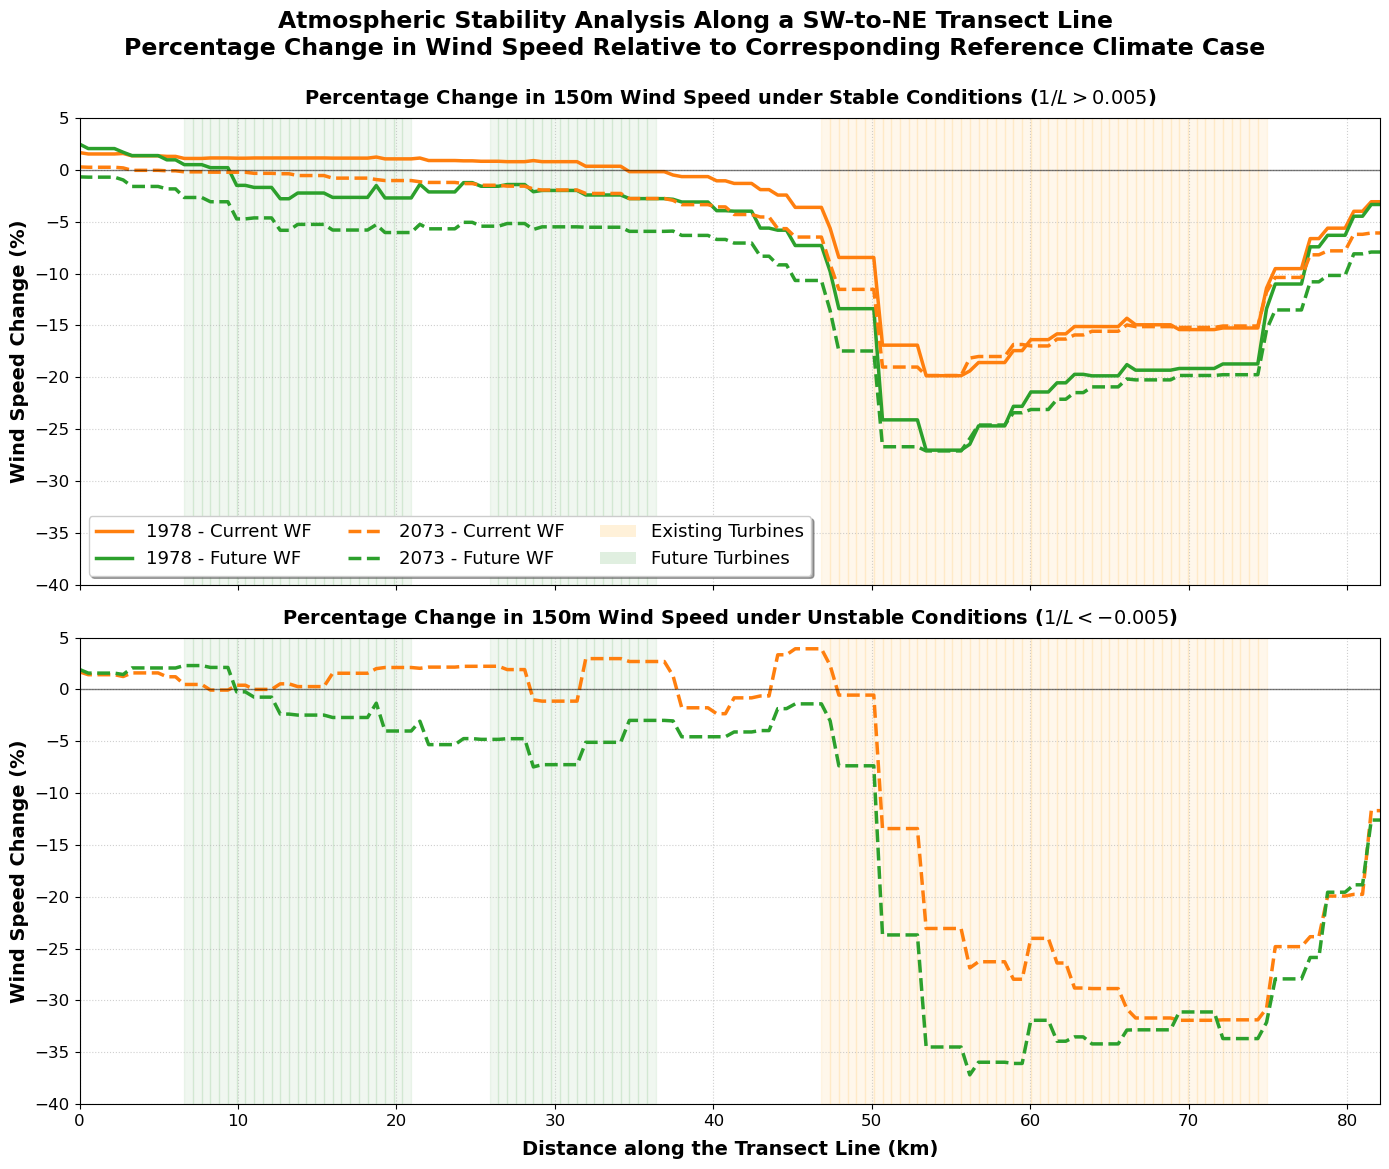

In [7]:
# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Define custom legend proxies for the background turbine zones
zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Map baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    # Skip plotting the flat control baselines (removes blue lines)
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            st_label = f"{label}" if '1994' in folder else f"{label}"
            line, = ax1.plot(distances_km, stable_diff, label=st_label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-40.0, 5)  # Enforces a matching identical scale across both profiles
    ax.tick_params(labelsize=12)

# Specific Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend Placement (Upper Right shifts it clear from crashing with profile curves)
ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

# Master Title Block Formatting
plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes_jan.png", dpi=300)
plt.show()

Found 31 matching daily files across all experiments.

Successfully processed 721 total hourly timestamps!
Folder: exp1994      | Stable Hours:   0 | Unstable Hours: 448
Folder: exp1994_WF   | Stable Hours:   0 | Unstable Hours: 448
Folder: exp1994_WFF  | Stable Hours:   0 | Unstable Hours: 448
Folder: experiment2  | Stable Hours:  10 | Unstable Hours: 468
Folder: exp2071_WF   | Stable Hours:  10 | Unstable Hours: 468
Folder: exp2071_WFF  | Stable Hours:  10 | Unstable Hours: 468


/tmp/ipykernel_2633429/975758628.py:284: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/975758628.py:285: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/975758628.py:287: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2633429/975758628.py:288: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


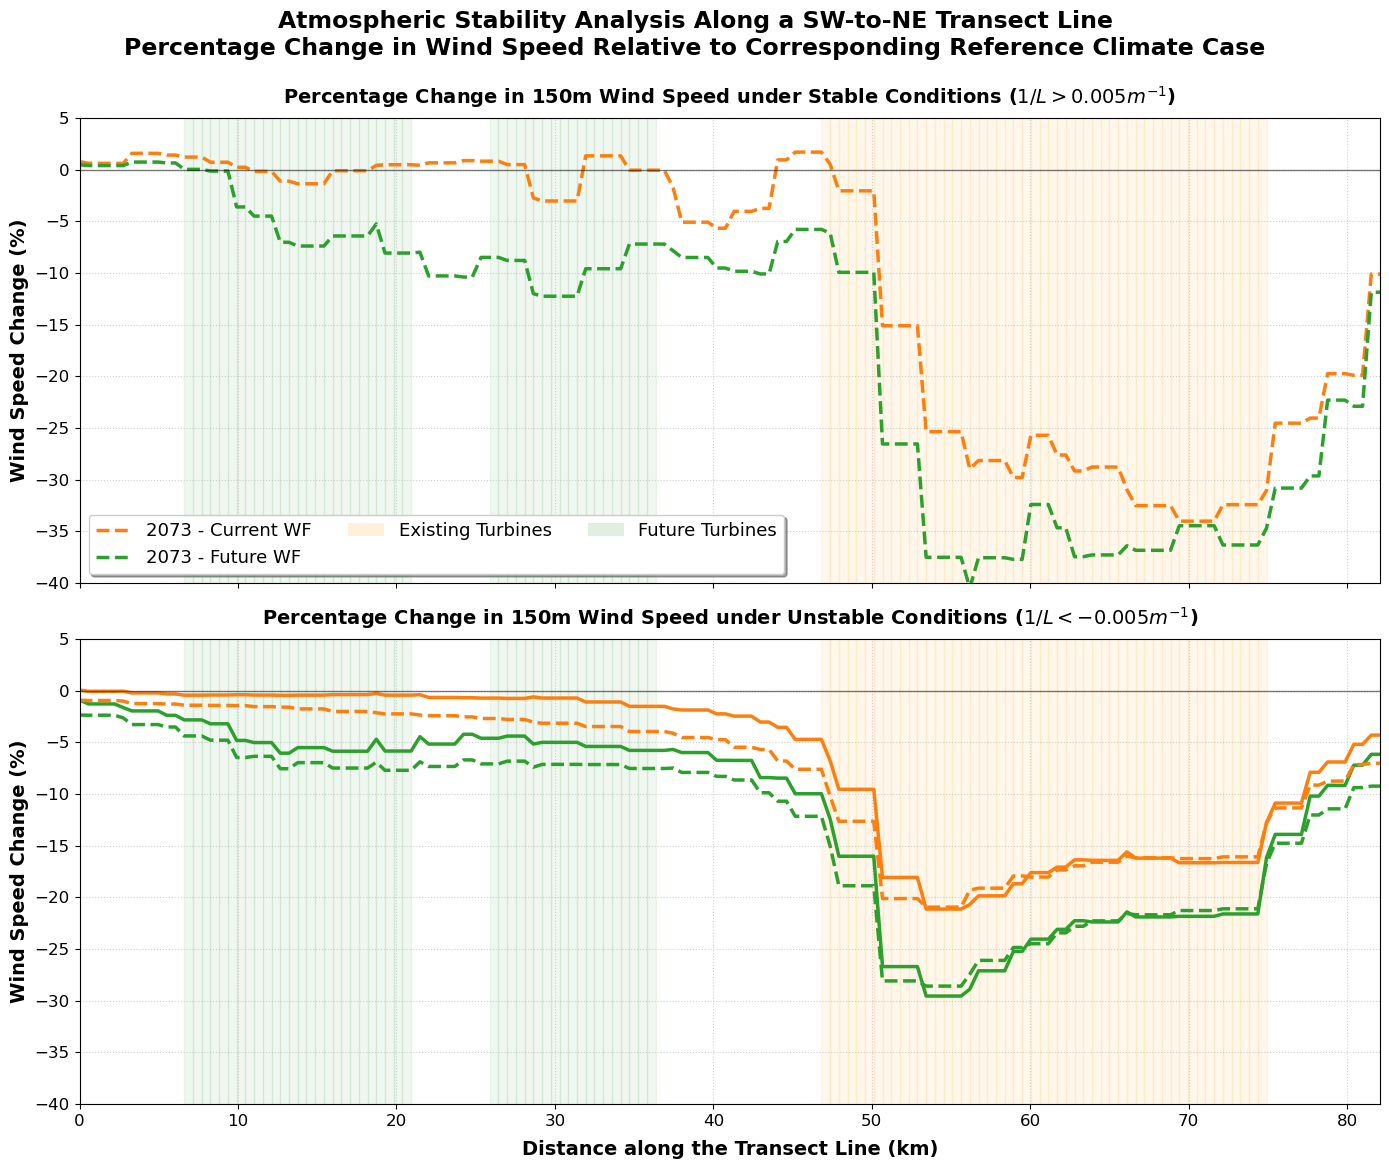

In [2]:
#### corridor average
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Duplicate-filtering engine
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    # FIXED: ll_to_xy returns (x_idx, y_idx)
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)


# --- 5. Synchronized Hourly Processing & Stability Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

stable_profiles = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
unstable_profiles = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
stable_hours = {exp[0]: 0 for exp in experiments}
unstable_hours = {exp[0]: 0 for exp in experiments}

# 1. Map files strictly by Day of Month (01 to 31) regardless of Year
def get_day_mapped_files(folder_name):
    folder_files = sorted(glob.glob(f"{base_path}{folder_name}/{file_pattern}"))
    mapped = {}
    for f in folder_files:
        # Matches the day number (e.g., -08-01_) regardless of whether year is 1994 or 2071
        match = re.search(r'-01-(\d{2})_', f)
        if match:
            day_key = match.group(1) # e.g. "01", "02", ..., "31"
            mapped[day_key] = f
    return mapped

exp_file_maps = {exp[0]: get_day_mapped_files(exp[0]) for exp in experiments}

# Find common days of the month across ALL experiments
common_days = set(exp_file_maps['exp1994'].keys())
for folder, _, _, _ in experiments:
    common_days = common_days.intersection(set(exp_file_maps[folder].keys()))

print(f"Found {len(common_days)} matching daily files across all experiments.")

x_arr = np.array(x_indices, dtype=int)
y_arr = np.array(y_indices, dtype=int)

total_processed_hours = 0

# Loop through each DAY OF THE MONTH ("01", "02", ...)
for day_key in sorted(list(common_days)):
    
    # Check how many time steps exist in this daily file
    nc_ref_1994_file = Dataset(exp_file_maps['exp1994'][day_key])
    num_timesteps = nc_ref_1994_file.dimensions['Time'].size
    nc_ref_1994_file.close()

    # Loop through EVERY HOUR (t_idx) in the daily file
    for t_idx in range(num_timesteps):
        total_processed_hours += 1
        
        # --- Step 1: 1994 Master Stability ---
        nc_ref_1994 = Dataset(exp_file_maps['exp1994'][day_key])
        hfx_94 = getvar(nc_ref_1994, "HFX", timeidx=t_idx).values
        th2_94 = getvar(nc_ref_1994, "TH2", timeidx=t_idx).values
        ust_94 = getvar(nc_ref_1994, "UST", timeidx=t_idx).values
        nc_ref_1994.close()

        y_max_94, x_max_94 = hfx_94.shape
        y_safe_94, x_safe_94 = np.clip(y_arr, 0, y_max_94 - 1), np.clip(x_arr, 0, x_max_94 - 1)

        # Correct formula with minus sign
        inv_L_94 = -(kappa * g * hfx_94) / (rho_cp * th2_94 * (np.maximum(ust_94, 1e-3)**3))
        mean_inv_L_94 = np.mean(inv_L_94[y_safe_94, x_safe_94])

        # --- Step 2: 2071 Master Stability ---
        nc_ref_2071 = Dataset(exp_file_maps['experiment2'][day_key])
        hfx_71 = getvar(nc_ref_2071, "HFX", timeidx=t_idx).values
        th2_71 = getvar(nc_ref_2071, "TH2", timeidx=t_idx).values
        ust_71 = getvar(nc_ref_2071, "UST", timeidx=t_idx).values
        nc_ref_2071.close()

        y_max_71, x_max_71 = hfx_71.shape
        y_safe_71, x_safe_71 = np.clip(y_arr, 0, y_max_71 - 1), np.clip(x_arr, 0, x_max_71 - 1)

        inv_L_71 = -(kappa * g * hfx_71) / (rho_cp * th2_71 * (np.maximum(ust_71, 1e-3)**3))
        mean_inv_L_71 = np.mean(inv_L_71[y_safe_71, x_safe_71])

        # --- Step 3: Accumulate Wind Speeds for All Experiments ---
        for folder, _, _, _ in experiments:
            current_mean_inv_L = mean_inv_L_94 if '1994' in folder else mean_inv_L_71
            
            regime = None
            if current_mean_inv_L > 0.005:      # True Stable
                regime = 'stable'
            elif current_mean_inv_L < -0.005:   # True Unstable
                regime = 'unstable'
                
            if regime:
                nc_exp = Dataset(exp_file_maps[folder][day_key])
                u = getvar(nc_exp, "ua", timeidx=t_idx, units="m s-1")
                v = getvar(nc_exp, "va", timeidx=t_idx, units="m s-1")
                height = getvar(nc_exp, "height_agl", timeidx=t_idx, units="m")
                
                wspd_150m = interplevel(np.sqrt(u**2 + v**2), height, TARGET_HEIGHT).values
                nc_exp.close()
                
                y_max_w, x_max_w = wspd_150m.shape
                y_safe_w, x_safe_w = np.clip(y_arr, 0, y_max_w - 1), np.clip(x_arr, 0, x_max_w - 1)
                
                transect_wspd = wspd_150m[y_safe_w, x_safe_w]
                
                if regime == 'stable':
                    stable_profiles[folder] += transect_wspd
                    stable_hours[folder] += 1
                elif regime == 'unstable':
                    unstable_profiles[folder] += transect_wspd
                    unstable_hours[folder] += 1

print(f"\nSuccessfully processed {total_processed_hours} total hourly timestamps!")

# --- Step 4: Final Averaging ---
final_stable = {}
final_unstable = {}
for folder, _, _, _ in experiments:
    print(f"Folder: {folder:12s} | Stable Hours: {stable_hours[folder]:3d} | Unstable Hours: {unstable_hours[folder]:3d}")
    if stable_hours[folder] > 0:
        final_stable[folder] = stable_profiles[folder] / stable_hours[folder]
    if unstable_hours[folder] > 0:
        final_unstable[folder] = unstable_profiles[folder] / unstable_hours[folder]

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

stable_ref_1994 = final_stable.get('exp1994')
stable_ref_2071 = final_stable.get('experiment2')
unstable_ref_1994 = final_unstable.get('exp1994')
unstable_ref_2071 = final_unstable.get('experiment2')

for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # Top Panel: STABLE WAKES
    if folder in final_stable:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((final_stable[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # Bottom Panel: UNSTABLE WAKES
    if folder in final_unstable:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((final_unstable[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-40.0, 5.0)  
    ax.tick_params(labelsize=12)

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300)
plt.show()

/tmp/ipykernel_2633429/3003801712.py:69: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/3003801712.py:70: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/3003801712.py:72: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2633429/3003801712.py:73: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


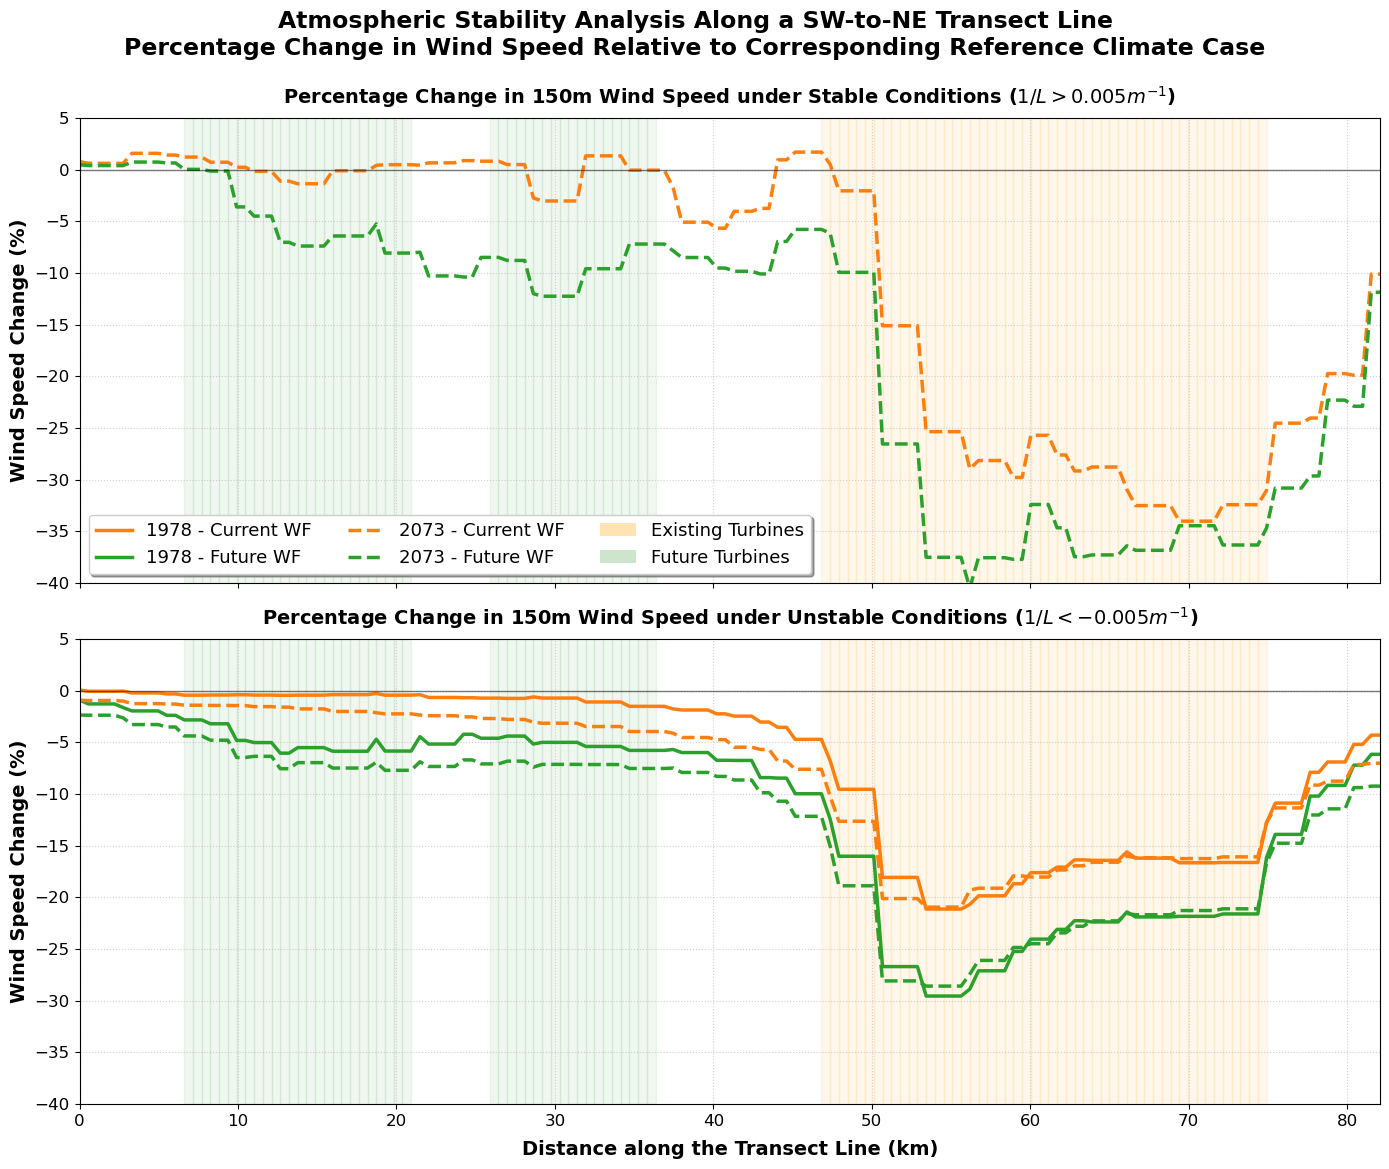

In [5]:
# --- 6. Plotting Two Panels ---
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# 1. Shading Patch Handles
zone_handles = [
    Patch(facecolor='orange', alpha=0.3, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.2, label='Future Turbines')
]

# 2. Build explicit Line Handles for ALL experiments from configuration
line_handles = [
    Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2.5, label=label)
    for folder, label, color, linestyle in experiments if folder not in ['exp1994', 'experiment2']
]

stable_ref_1994 = final_stable.get('exp1994')
stable_ref_2071 = final_stable.get('experiment2')
unstable_ref_1994 = final_unstable.get('exp1994')
unstable_ref_2071 = final_unstable.get('experiment2')

# Plot actual data differences where available
for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # Top Panel: STABLE WAKES
    if folder in final_stable:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((final_stable[folder] - st_ref) / st_ref) * 100
            ax1.plot(distances_km, stable_diff, color=color, linestyle=linestyle, linewidth=2.5)
            
    # Bottom Panel: UNSTABLE WAKES
    if folder in final_unstable:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((final_unstable[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-40.0, 5.0)  
    ax.tick_params(labelsize=12)

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend featuring ALL configured experiments + shading zones
ax1.legend(
    handles=line_handles + zone_handles, 
    loc='lower left', 
    fontsize=13, 
    frameon=True, 
    ncol=3, 
    shadow=True, 
    facecolor='white'
)
# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes.png", dpi=300)
plt.show()

Found 31 matching daily files across all experiments.

Successfully processed 721 total hourly timestamps!


/tmp/ipykernel_2668145/362468180.py:278: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2668145/362468180.py:279: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2668145/362468180.py:281: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2668145/362468180.py:282: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


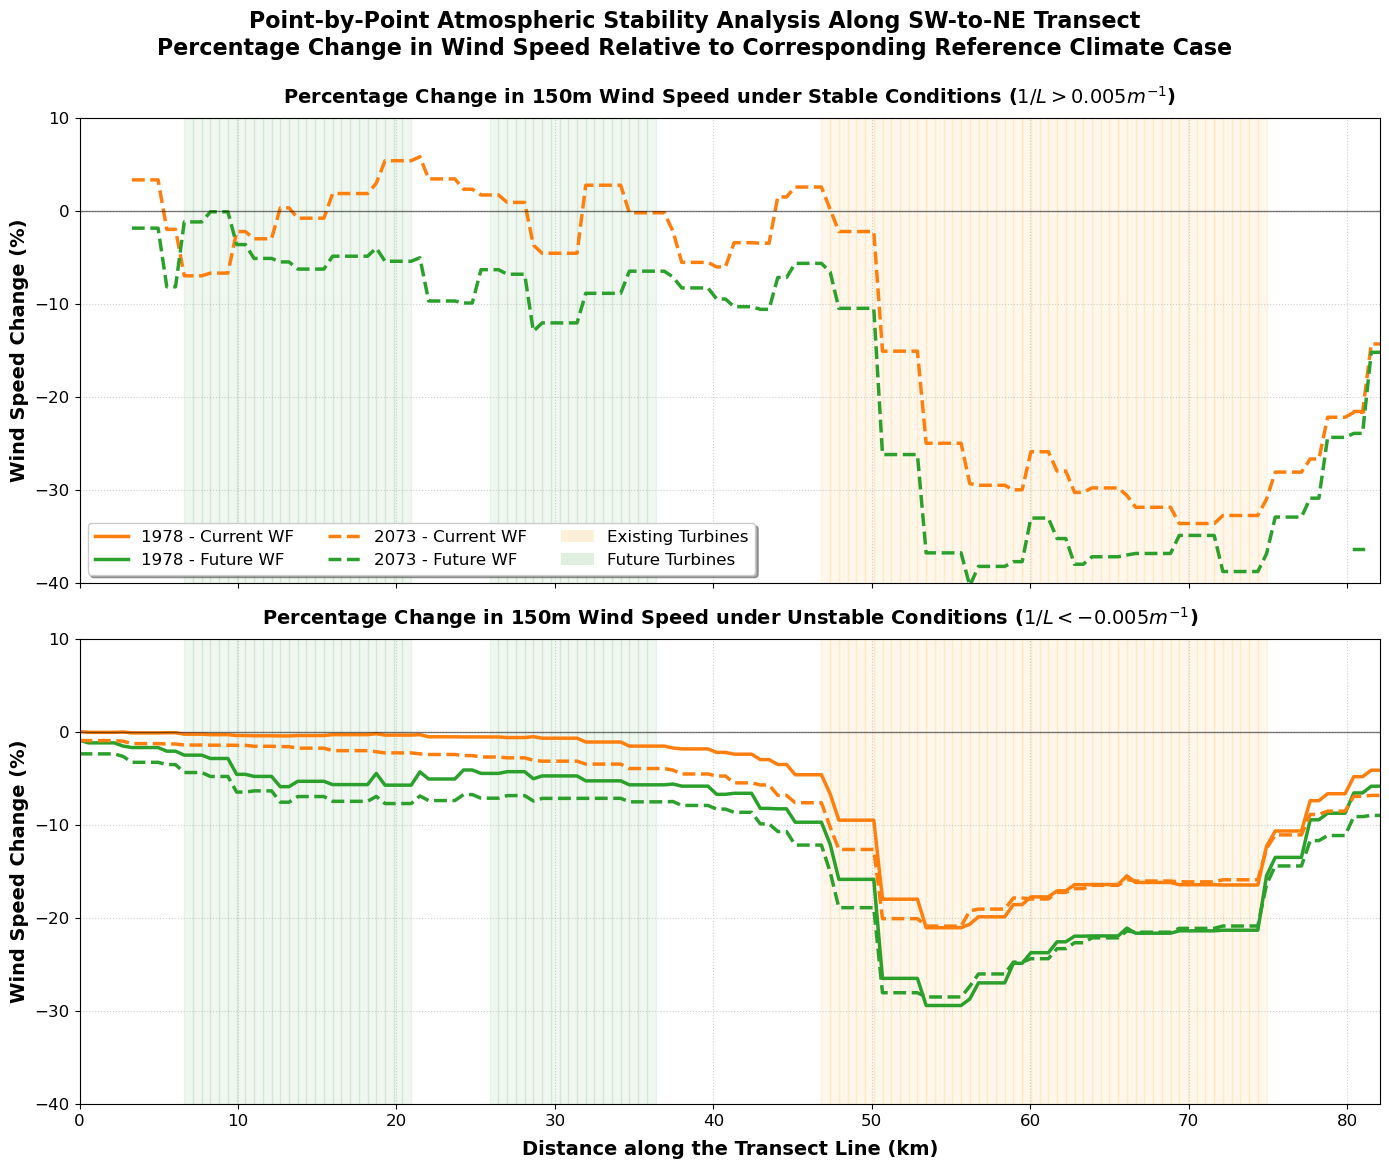

In [3]:
#### point by point
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - no WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - no WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Duplicate-filtering engine
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    # FIXED: ll_to_xy returns (x_idx, y_idx)
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)


# --- 5. Hourly Synchronized Processing & Point-by-Point Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# Arrays to accumulate wind speed and hour counts at each point along transect (150 points)
stable_wspd_sum = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
stable_point_hours = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}

unstable_wspd_sum = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}
unstable_point_hours = {exp[0]: np.zeros(NUM_POINTS) for exp in experiments}

# Convert list indices to NumPy arrays for fast 2D slicing
x_arr = np.array(x_indices, dtype=int)
y_arr = np.array(y_indices, dtype=int)

# Map files strictly by Day of Month (01 to 31) regardless of Year in file name
def get_day_mapped_files(folder_name):
    folder_files = sorted(glob.glob(f"{base_path}{folder_name}/{file_pattern}"))
    mapped = {}
    for f in folder_files:
        match = re.search(r'-01-(\d{2})_', f)
        if match:
            day_key = match.group(1) # e.g., "01", "02", ..., "31"
            mapped[day_key] = f
    return mapped

exp_file_maps = {exp[0]: get_day_mapped_files(exp[0]) for exp in experiments}

# Find common days of the month across ALL experiments
common_days = set(exp_file_maps['exp1994'].keys())
for folder, _, _, _ in experiments:
    common_days = common_days.intersection(set(exp_file_maps[folder].keys()))

print(f"Found {len(common_days)} matching daily files across all experiments.")

total_processed_hours = 0

# Loop through each DAY OF THE MONTH ("01", "02", ..., "31")
for day_key in sorted(list(common_days)):
    
    # Check how many time steps exist in this daily file (usually 24)
    nc_ref_1994 = Dataset(exp_file_maps['exp1994'][day_key])
    num_timesteps = nc_ref_1994.dimensions['Time'].size
    nc_ref_1994.close()

    # Loop through EVERY HOUR (t_idx) in the daily file
    for t_idx in range(num_timesteps):
        total_processed_hours += 1
        
        # 1. Load Data for ALL 6 Experiments at this exact timestamp (t_idx)
        wspd_transect_dict = {}
        inv_L_transect_dict = {}
        
        for folder, _, _, _ in experiments:
            nc_exp = Dataset(exp_file_maps[folder][day_key])
            
            # Wind speed at 150m
            u = getvar(nc_exp, "ua", timeidx=t_idx, units="m s-1", meta=False)
            v = getvar(nc_exp, "va", timeidx=t_idx, units="m s-1", meta=False)
            height = getvar(nc_exp, "height_agl", timeidx=t_idx, units="m", meta=False)
            wspd_3d = np.sqrt(u**2 + v**2)
            wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT, meta=False)
            
            # Surface stability variables
            ust = getvar(nc_exp, "UST", timeidx=t_idx, meta=False)
            hfx = getvar(nc_exp, "HFX", timeidx=t_idx, meta=False)
            th2 = getvar(nc_exp, "TH2", timeidx=t_idx, meta=False)
            nc_exp.close()
            
            # Obukhov Length (1/L) field
            ust_safe = np.maximum(ust, 1e-3)
            inv_L = -(kappa * g * hfx) / (rho_cp * th2 * (ust_safe**3))
            
            # Slice transect points dynamically
            wspd_transect_dict[folder] = wspd_150m[y_arr, x_arr]
            inv_L_transect_dict[folder] = inv_L[y_arr, x_arr]

        # 2. Accumulate Point-by-Point Stratified Data for Each Experiment
        for folder, _, _, _ in experiments:
            # Determine which climate reference stability field to use for stratification
            ref_folder = 'exp1994' if '1994' in folder else 'experiment2'
            transect_inv_L = inv_L_transect_dict[ref_folder] # Point-by-point stability of corresponding control
            
            transect_wspd = wspd_transect_dict[folder]
            
            # Point-by-Point Masks along transect
            stable_mask = transect_inv_L > 0.005
            unstable_mask = transect_inv_L < -0.005
            
            # Accumulate sum and hour counts per point
            stable_wspd_sum[folder][stable_mask] += transect_wspd[stable_mask]
            stable_point_hours[folder][stable_mask] += 1
            
            unstable_wspd_sum[folder][unstable_mask] += transect_wspd[unstable_mask]
            unstable_point_hours[folder][unstable_mask] += 1

print(f"\nSuccessfully processed {total_processed_hours} total hourly timestamps!")

# --- Compute Final Mean Profiles ---
stable_profiles = {}
unstable_profiles = {}

for folder, _, _, _ in experiments:
    with np.errstate(divide='ignore', invalid='ignore'):
        stable_profiles[folder] = np.where(
            stable_point_hours[folder] > 0, 
            stable_wspd_sum[folder] / stable_point_hours[folder], 
            np.nan
        )
        unstable_profiles[folder] = np.where(
            unstable_point_hours[folder] > 0, 
            unstable_wspd_sum[folder] / unstable_point_hours[folder], 
            np.nan
        )

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Custom legend proxies for turbine zones
zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    # Skip plotting the control baselines directly
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-40, 10)  # Enforces a matching identical scale across both profiles
    ax.tick_params(labelsize=12)

# Dynamic Shading Implementation for Turbines
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

# Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

# Unified Legend
ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=12, frameon=True, ncol=3, shadow=True, facecolor='white')

# Master Title Block
plt.suptitle("Point-by-Point Atmospheric Stability Analysis Along SW-to-NE Transect\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=16, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_point_by_point_stratified_wakes.png", dpi=300)
plt.show()

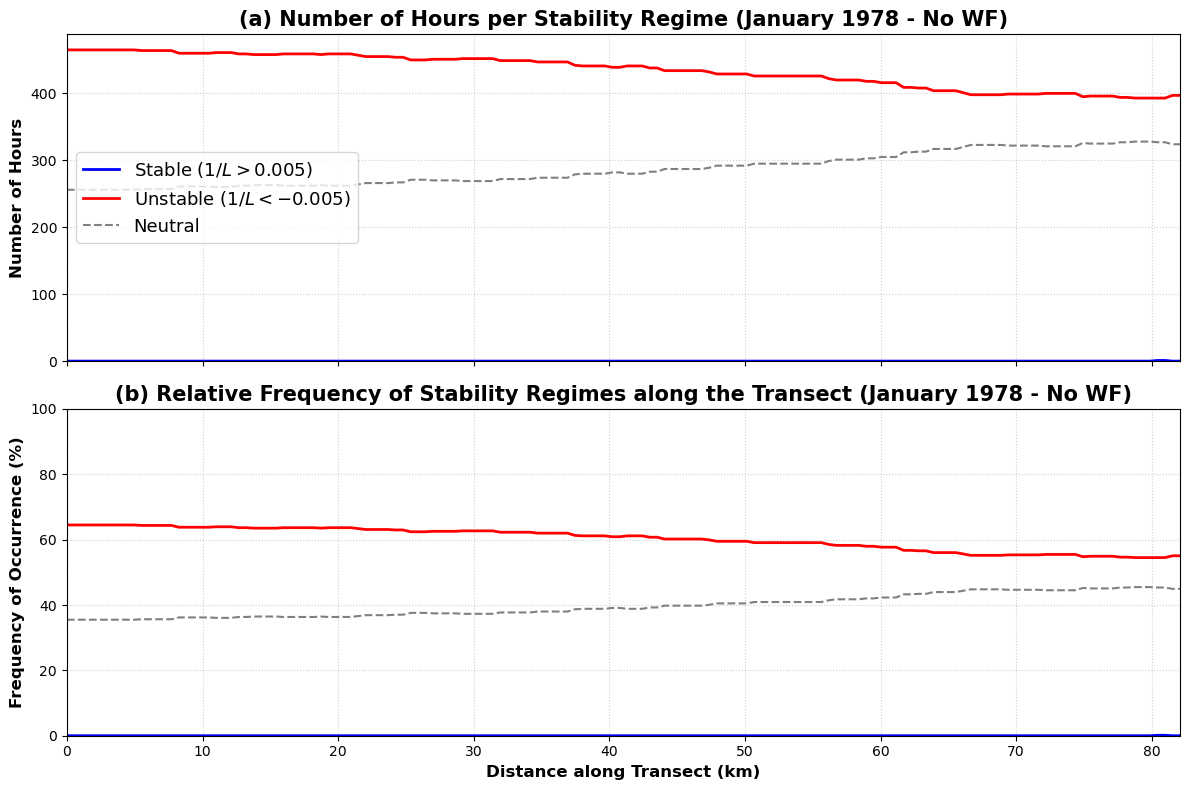

In [8]:
# Create a dedicated diagnostic figure for your thesis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Calculate neutral hours as the remaining hours
# Assuming ref_folder 'exp1994' for baseline stability counts
total_hours = total_processed_hours
st_hours = stable_point_hours['exp1994']
unst_hours = unstable_point_hours['exp1994']
neu_hours = total_hours - (st_hours + unst_hours)

# Panel 1: Absolute Hours Count
ax1.plot(distances_km, st_hours, color='blue', linewidth=2, label='Stable ($1/L > 0.005$)')
ax1.plot(distances_km, unst_hours, color='red', linewidth=2, label='Unstable ($1/L < -0.005$)')
ax1.plot(distances_km, neu_hours, color='gray', linestyle='--', linewidth=1.5, label='Neutral')

ax1.set_ylabel("Number of Hours", fontsize=12, fontweight='bold')
ax1.set_title("(a) Number of Hours per Stability Regime (January 1978 - No WF)", fontsize=15, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='center left', frameon=True, fontsize=13)

# Panel 2: Percentage Occurrence
ax2.plot(distances_km, (st_hours / total_hours) * 100, color='blue', linewidth=2, label='Stable %')
ax2.plot(distances_km, (unst_hours / total_hours) * 100, color='red', linewidth=2, label='Unstable %')
ax2.plot(distances_km, (neu_hours / total_hours) * 100, color='gray', linestyle='--', linewidth=1.5, label='Neutral %')

ax2.set_ylabel("Frequency of Occurrence (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance along Transect (km)", fontsize=12, fontweight='bold')
ax2.set_title("(b) Relative Frequency of Stability Regimes along the Transect (January 1978 - No WF)", fontsize=15, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- AXIS OFFSET FIX ---
# 1. Force X-axis to start exactly at 0 km and end at the max distance
ax1.set_xlim(left=0, right=max(distances_km))  # Applies to ax2 automatically because sharex=True

# 2. Force Y-axes to start at 0
ax1.set_ylim(bottom=0)                         # Let top scale dynamically to maximum hours
ax2.set_ylim(bottom=0, top=100)               # Hard-code 0% to 100%

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_sample_sizes.png", dpi=300)
plt.show()

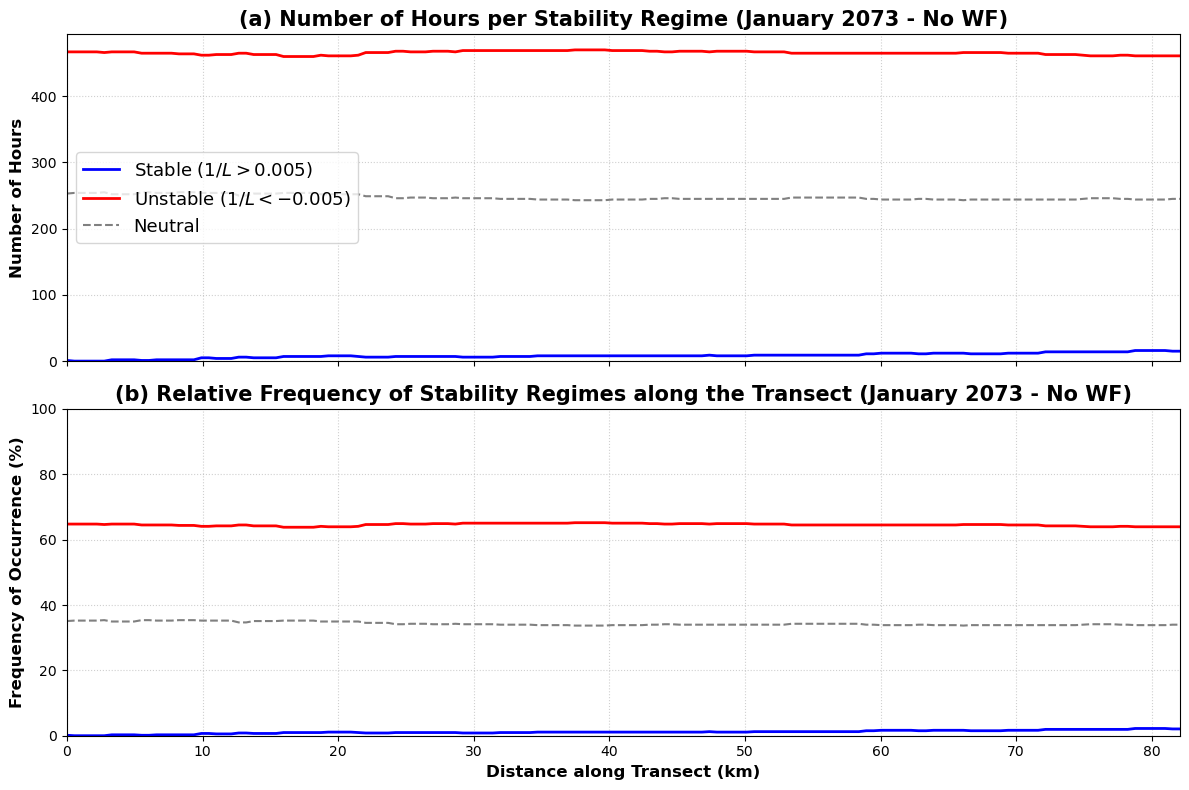

In [9]:
# Create a dedicated diagnostic figure for your thesis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Calculate neutral hours as the remaining hours
# Assuming ref_folder 'exp1994' for baseline stability counts
total_hours = total_processed_hours
st_hours = stable_point_hours['experiment2']
unst_hours = unstable_point_hours['experiment2']
neu_hours = total_hours - (st_hours + unst_hours)

# Panel 1: Absolute Hours Count
ax1.plot(distances_km, st_hours, color='blue', linewidth=2, label='Stable ($1/L > 0.005$)')
ax1.plot(distances_km, unst_hours, color='red', linewidth=2, label='Unstable ($1/L < -0.005$)')
ax1.plot(distances_km, neu_hours, color='gray', linestyle='--', linewidth=1.5, label='Neutral')

ax1.set_ylabel("Number of Hours", fontsize=12, fontweight='bold')
ax1.set_title("(a) Number of Hours per Stability Regime (January 2073 - No WF)", fontsize=15, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='center left', frameon=True, fontsize=13)

# Panel 2: Percentage Occurrence
ax2.plot(distances_km, (st_hours / total_hours) * 100, color='blue', linewidth=2, label='Stable %')
ax2.plot(distances_km, (unst_hours / total_hours) * 100, color='red', linewidth=2, label='Unstable %')
ax2.plot(distances_km, (neu_hours / total_hours) * 100, color='gray', linestyle='--', linewidth=1.5, label='Neutral %')

ax2.set_ylabel("Frequency of Occurrence (%)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Distance along Transect (km)", fontsize=12, fontweight='bold')
ax2.set_title("(b) Relative Frequency of Stability Regimes along the Transect (January 2073 - No WF)", fontsize=15, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# --- AXIS OFFSET FIX ---
# 1. Force X-axis to start exactly at 0 km and end at the max distance
ax1.set_xlim(left=0, right=max(distances_km))  # Applies to ax2 automatically because sharex=True

# 2. Force Y-axes to start at 0
ax1.set_ylim(bottom=0)                         # Let top scale dynamically to maximum hours
ax2.set_ylim(bottom=0, top=100)               # Hard-code 0% to 100%

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_sample_sizes.png", dpi=300)
plt.show()

Extracting profile data for 1978 - No WF: found 31 daily files.
  --> Total extracted hours for 1978 - No WF: 721 hours.
Extracting profile data for 1978 - Current WF: found 31 daily files.
  --> Total extracted hours for 1978 - Current WF: 721 hours.
Extracting profile data for 1978 - Future WF: found 31 daily files.
  --> Total extracted hours for 1978 - Future WF: 721 hours.
Extracting profile data for 2073 - No WF: found 31 daily files.
  --> Total extracted hours for 2073 - No WF: 744 hours.
Extracting profile data for 2073 - Current WF: found 31 daily files.
  --> Total extracted hours for 2073 - Current WF: 744 hours.
Extracting profile data for 2073 - Future WF: found 31 daily files.
  --> Total extracted hours for 2073 - Future WF: 744 hours.


/tmp/ipykernel_2510480/4154405679.py:197: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_2510480/4154405679.py:200: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


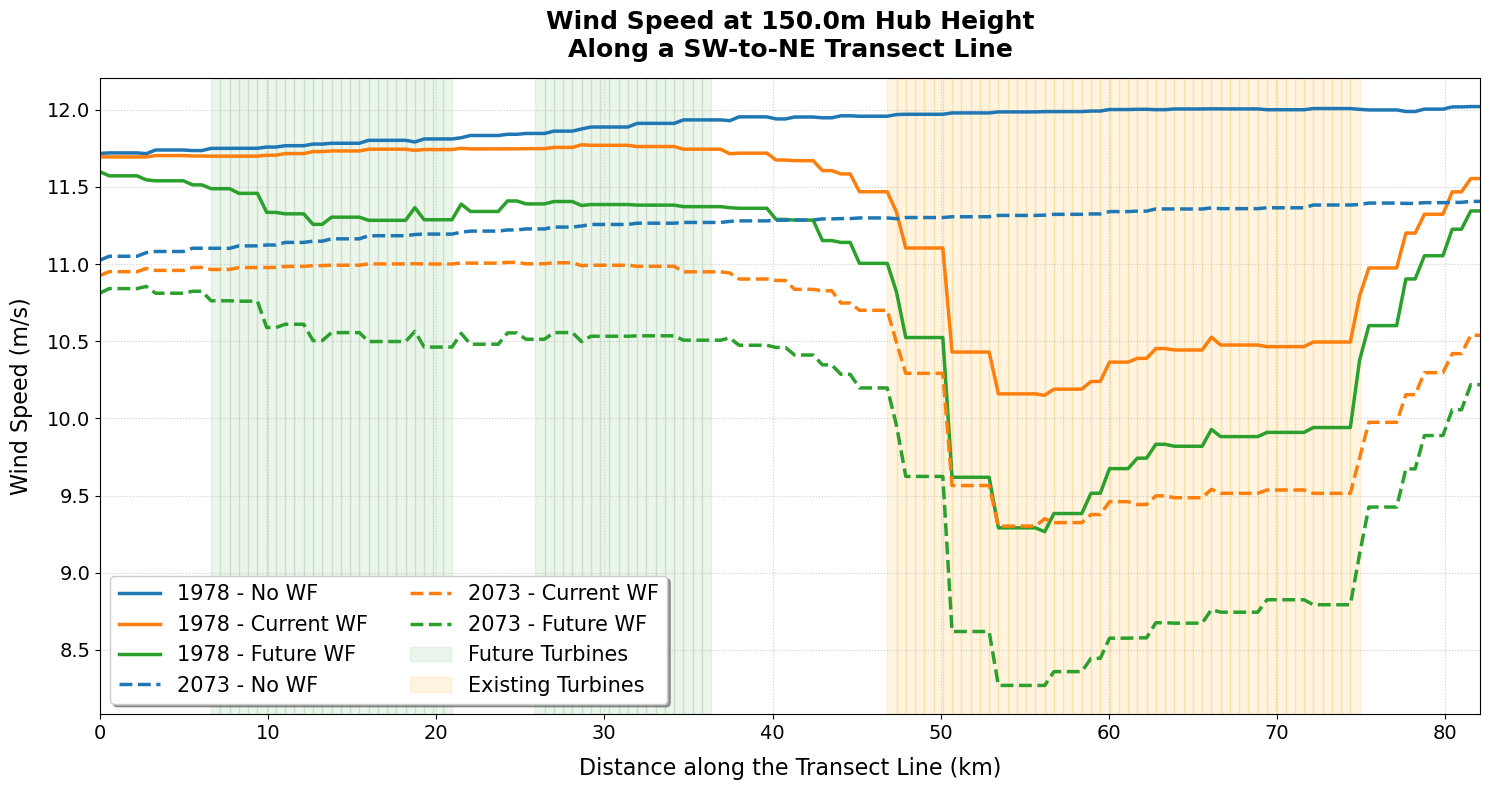

In [ ]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - No WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT (Matches your updated map exactly)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the exact duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
# If a point along the profile comes within ~2.5 km of a turbine dot, flag it for shading
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)


# --- 5. Processing NetCDF Wind Fields (All January Hours) ---
plt.figure(figsize=(15, 8))

# Strict file pattern matching YYYY-01-DD
strict_jan_pattern = 'WRF/run/wrfout_d03_*-01-??_*'

for folder, label, color, linestyle in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{strict_jan_pattern}"))
    
    if not files: 
        print(f"WARNING: No files found for {label} in folder {folder}")
        continue
        
    print(f"Extracting profile data for {label}: found {len(files)} daily files.")
    
    sum_wspd_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        # Extract full time dimension at once
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        wspd_hourly = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_hourly, height, TARGET_HEIGHT)
        
        hours_in_file = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        wspd_sum = np.sum(wspd_150m.values, axis=0) if wspd_150m.ndim == 3 else wspd_150m.values
        
        if sum_wspd_150m is None: 
            sum_wspd_150m = wspd_sum
        else: 
            sum_wspd_150m += wspd_sum
            
        total_hours += hours_in_file
        nc.close()
        
    print(f"  --> Total extracted hours for {label}: {total_hours} hours.")
    
    mean_wspd_grid = sum_wspd_150m / total_hours
    
    # Fast vectorized numpy slicing along transect
    x_arr = np.clip(np.array(x_indices, dtype=int), 0, mean_wspd_grid.shape[1] - 1)
    y_arr = np.clip(np.array(y_indices, dtype=int), 0, mean_wspd_grid.shape[0] - 1)
    transect_values = mean_wspd_grid[y_arr, x_arr]
    
    plt.plot(distances_km, transect_values, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 6. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

plt.title(f"Wind Speed at {TARGET_HEIGHT}m Hub Height\nAlong a SW-to-NE Transect Line", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed (m/s)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='lower left', fontsize=15, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_comparison_january_wakes.png", dpi=300)
plt.show()

Extracting profile data for: 1978 - No WF...
Extracting profile data for: 1978 - Current WF...
Extracting profile data for: 1978 - Future WF...
Extracting profile data for: 2073 - No WF...
Extracting profile data for: 2073 - Current WF...
Extracting profile data for: 2073 - Future WF...


/tmp/ipykernel_398733/3590757436.py:173: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_398733/3590757436.py:176: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


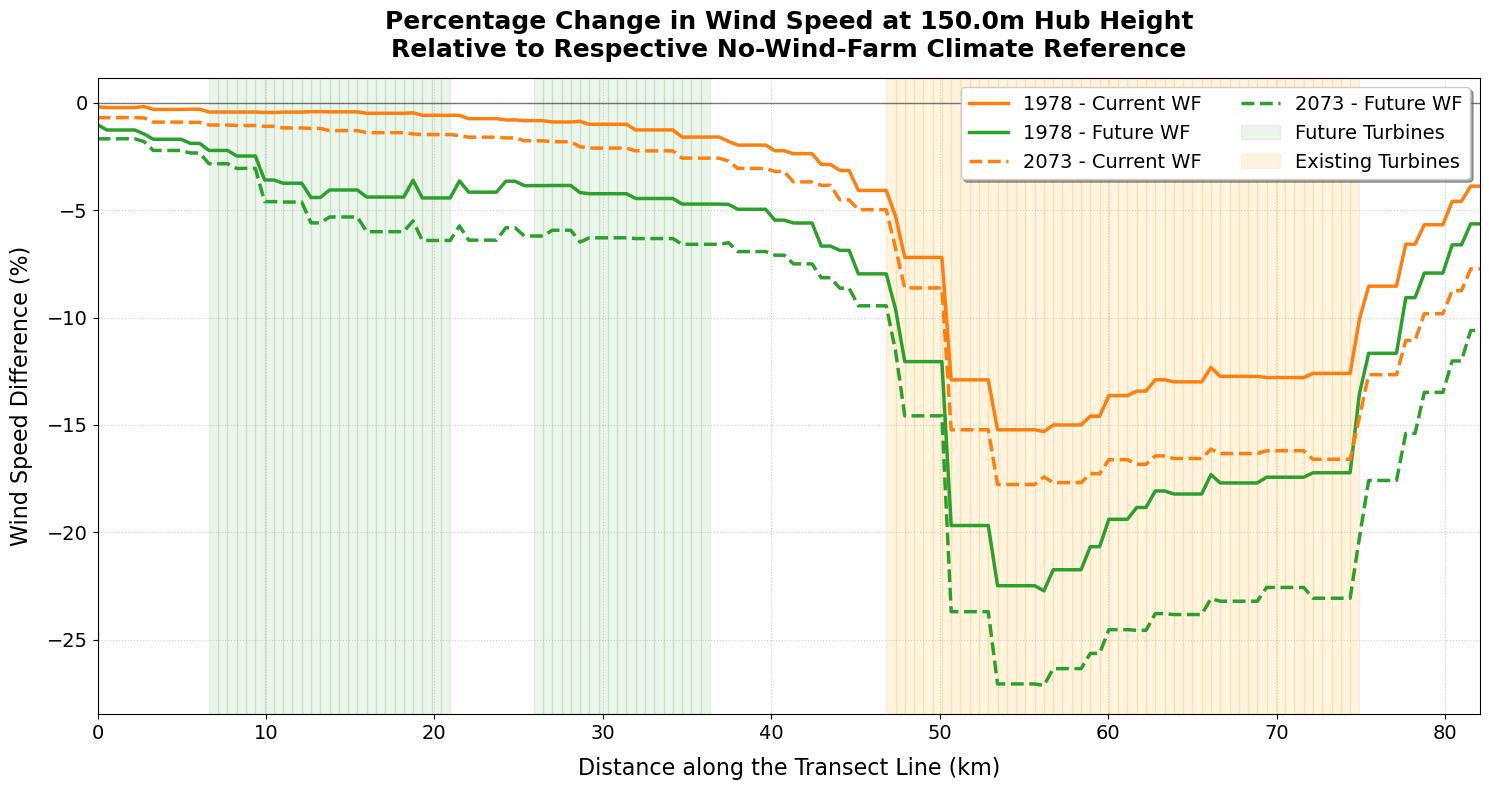

In [7]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - No WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing & Storing Wind Fields ---
profile_results = {}

for folder, label, color, linestyle in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30] 
    
    if not files: continue
    print(f"Extracting profile data for: {label}...")
    
    sum_wspd_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        wspd_hourly = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_hourly, height, TARGET_HEIGHT)
        
        hours_in_file = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        wspd_sum = np.sum(wspd_150m.values, axis=0) if wspd_150m.ndim == 3 else wspd_150m.values
        
        if sum_wspd_150m is None: sum_wspd_150m = wspd_sum
        else: sum_wspd_150m += wspd_sum
        total_hours += hours_in_file
        nc.close()
        
    mean_wspd_grid = sum_wspd_150m / total_hours
    # Save absolute values into dictionary for post-processing calculation
    profile_results[folder] = np.array([mean_wspd_grid[y, x] for y, x in zip(y_indices, x_indices)])

# --- 6. Calculate Differences and Plot ---
plt.figure(figsize=(15, 8))

# Map baseline keys
ref_1994 = profile_results['exp1994']
ref_2071 = profile_results['experiment2']

for folder, label, color, linestyle in experiments:
    
    if folder in ['exp1994', 'experiment2']:
        continue
    
    # 1. Determine the contextually appropriate control run and update legend label
    if '1994' in folder:
        control_ref = ref_1994
        if folder == 'exp1994':
            plot_label = '1994 Baseline Reference (0%)'
        else:
            plot_label = f"{label}"
    else:
        control_ref = ref_2071
        if folder == 'experiment2':
            plot_label = '2071 Baseline Reference (0%)'
        else:
            plot_label = f"{label}"
        
    # 2. Calculate % difference: ((Case - Reference) / Reference) * 100
    pct_diff = ((profile_results[folder] - control_ref) / control_ref) * 100
    
    # 3. Plot with the corrected label
    plt.plot(distances_km, pct_diff, label=plot_label, color=color, linestyle=linestyle, linewidth=2.5)
    
# --- 7. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

# Horizontal reference line at 0%
plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)

plt.title(f"Percentage Change in Wind Speed at {TARGET_HEIGHT}m Hub Height\nRelative to Respective No-Wind-Farm Climate Reference", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed Difference (%)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='upper right', fontsize=14, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_percentage_change_january_wakes.png", dpi=300)
plt.show()    

Extracting profile data for 1978 - No WF: processing 31 daily files...
  --> Extracted 721 total hours for exp1994.
Extracting profile data for 1978 - Current WF: processing 31 daily files...
  --> Extracted 721 total hours for exp1994_WF.
Extracting profile data for 1978 - Future WF: processing 31 daily files...
  --> Extracted 721 total hours for exp1994_WFF.
Extracting profile data for 2073 - No WF: processing 31 daily files...
  --> Extracted 744 total hours for experiment2.
Extracting profile data for 2073 - Current WF: processing 31 daily files...
  --> Extracted 744 total hours for exp2071_WF.
Extracting profile data for 2073 - Future WF: processing 31 daily files...
  --> Extracted 744 total hours for exp2071_WFF.


/tmp/ipykernel_2510480/1963287443.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_2510480/1963287443.py:174: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


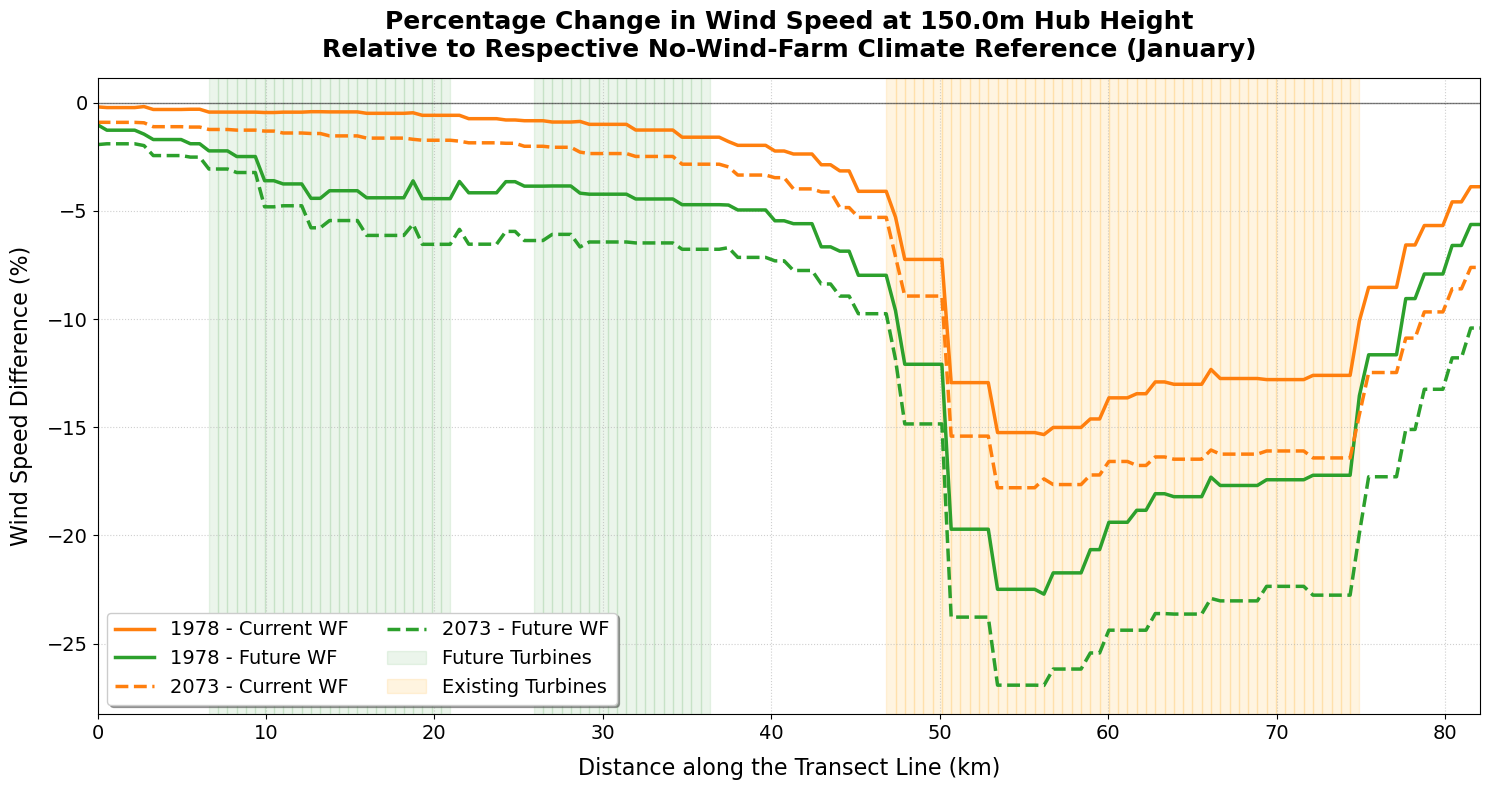

In [2]:
# good jan hour
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - No WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

# Strict January pattern: YYYY-01-DD_hh:mm:ss
file_pattern = 'WRF/run/wrfout_d03_*-01-??_*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Processing & Storing Wind Fields ---
profile_results = {}

for folder, label, color, linestyle in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    
    if not files: 
        print(f"WARNING: No files found for folder: {folder}")
        continue
        
    print(f"Extracting profile data for {label}: processing {len(files)} daily files...")
    
    sum_wspd_150m = None
    total_hours = 0
    
    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1")
        v = getvar(nc, "va", timeidx=None, units="m s-1")
        height = getvar(nc, "height_agl", timeidx=None, units="m")
        
        wspd_hourly = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_hourly, height, TARGET_HEIGHT)
        
        hours_in_file = wspd_150m.shape[0] if wspd_150m.ndim == 3 else 1
        wspd_sum = np.sum(wspd_150m.values, axis=0) if wspd_150m.ndim == 3 else wspd_150m.values
        
        if sum_wspd_150m is None: 
            sum_wspd_150m = wspd_sum
        else: 
            sum_wspd_150m += wspd_sum
            
        total_hours += hours_in_file
        nc.close()
        
    print(f"  --> Extracted {total_hours} total hours for {folder}.")
    mean_wspd_grid = sum_wspd_150m / total_hours
    
    # Vectorized indexing along transect line
    y_safe = np.clip(np.array(y_indices, dtype=int), 0, mean_wspd_grid.shape[0] - 1)
    x_safe = np.clip(np.array(x_indices, dtype=int), 0, mean_wspd_grid.shape[1] - 1)
    
    profile_results[folder] = mean_wspd_grid[y_safe, x_safe]

# --- 6. Calculate Differences and Plot ---
plt.figure(figsize=(15, 8))

ref_1994 = profile_results['exp1994']
ref_2071 = profile_results['experiment2']

for folder, label, color, linestyle in experiments:
    # Skip baseline reference cases on the plot
    if folder in ['exp1994', 'experiment2']:
        continue
    
    control_ref = ref_1994 if '1994' in folder else ref_2071
    
    # % difference: ((Case - Control) / Control) * 100
    pct_diff = ((profile_results[folder] - control_ref) / control_ref) * 100
    
    plt.plot(distances_km, pct_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 7. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)

plt.title(f"Percentage Change in Wind Speed at {TARGET_HEIGHT}m Hub Height\nRelative to Respective No-Wind-Farm Climate Reference (January)", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed Difference (%)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='lower left', fontsize=14, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_percentage_change_january_wakes.png", dpi=300)
plt.show()

/tmp/ipykernel_2510480/1506934570.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
/tmp/ipykernel_2510480/1506934570.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',


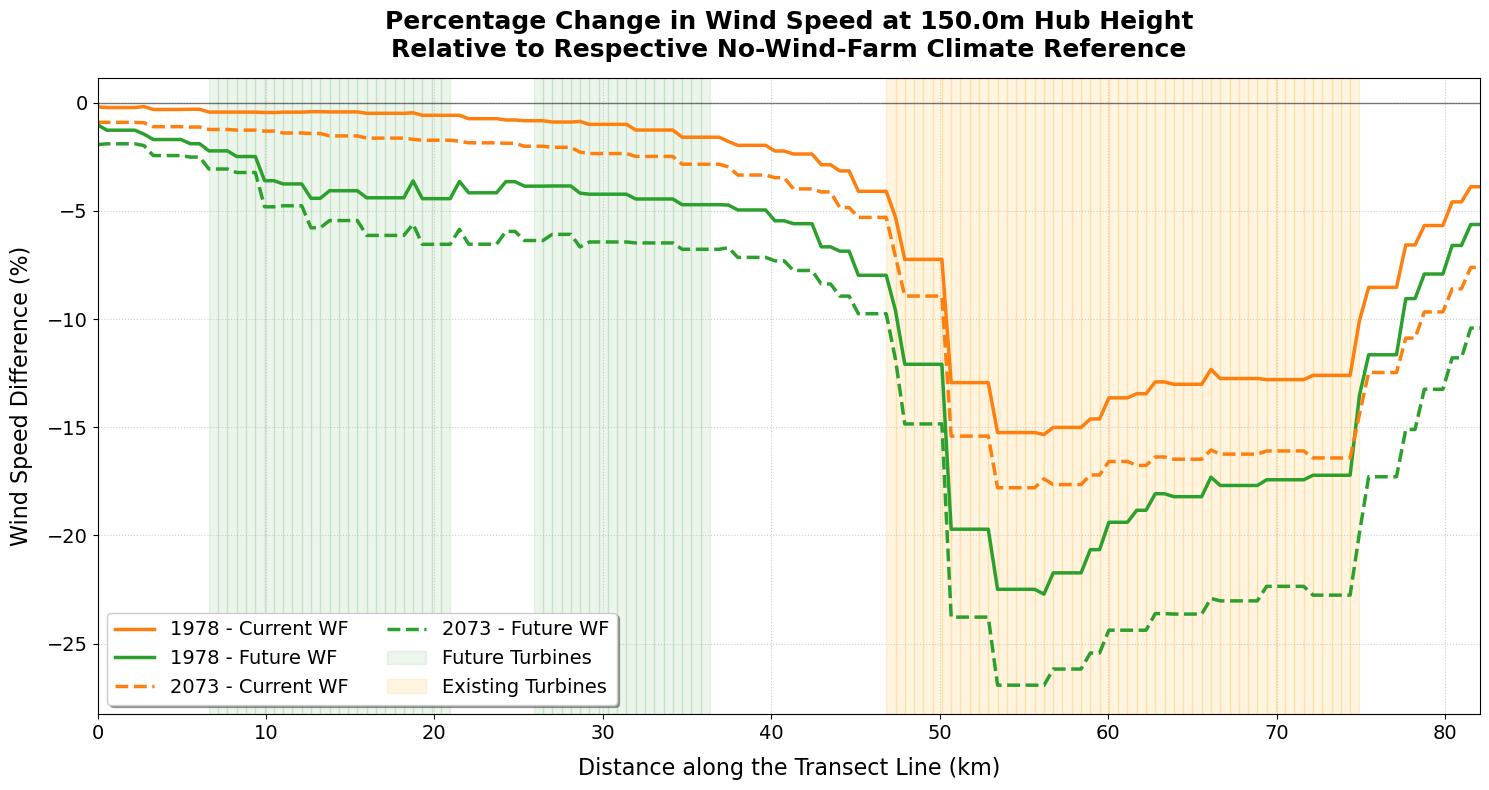

In [3]:
# --- 6. Calculate Differences and Plot ---
plt.figure(figsize=(15, 8))

ref_1994 = profile_results['exp1994']
ref_2071 = profile_results['experiment2']

for folder, label, color, linestyle in experiments:
    # Skip baseline reference cases on the plot
    if folder in ['exp1994', 'experiment2']:
        continue
    
    control_ref = ref_1994 if '1994' in folder else ref_2071
    
    # % difference: ((Case - Control) / Control) * 100
    pct_diff = ((profile_results[folder] - control_ref) / control_ref) * 100
    
    plt.plot(distances_km, pct_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)

# --- 7. Dynamic Shading & Plot Styling ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.08, edgecolor='none',
                    label='Future Turbines' if i == min(idx for idx, m in enumerate(future_mask) if m) else "")
    if current_mask[i]:
        plt.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.12, edgecolor='none',
                    label='Existing Turbines' if i == min(idx for idx, m in enumerate(current_mask) if m) else "")

plt.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)

plt.title(f"Percentage Change in Wind Speed at {TARGET_HEIGHT}m Hub Height\nRelative to Respective No-Wind-Farm Climate Reference", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Distance along the Transect Line (km)", fontsize=16, labelpad=10)
plt.ylabel("Wind Speed Difference (%)", fontsize=16, labelpad=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, max(distances_km))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc='lower left', fontsize=14, frameon=True, shadow=True, facecolor='white', ncol=2)
plt.tight_layout()
plt.savefig(f"{base_path}transect_percentage_change_january_wakes.png", dpi=300)
plt.show()

Point by point stratification

Stratifying data point-by-point for: 1978 - No WF...
Stratifying data point-by-point for: 1978 - Current WF...
Stratifying data point-by-point for: 1978 - Future WF...
Stratifying data point-by-point for: 2073 - No WF...
Stratifying data point-by-point for: 2073 - Current WF...
Stratifying data point-by-point for: 2073 - Future WF...


/tmp/ipykernel_2633429/3915291241.py:245: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/3915291241.py:246: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_2633429/3915291241.py:248: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_2633429/3915291241.py:249: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


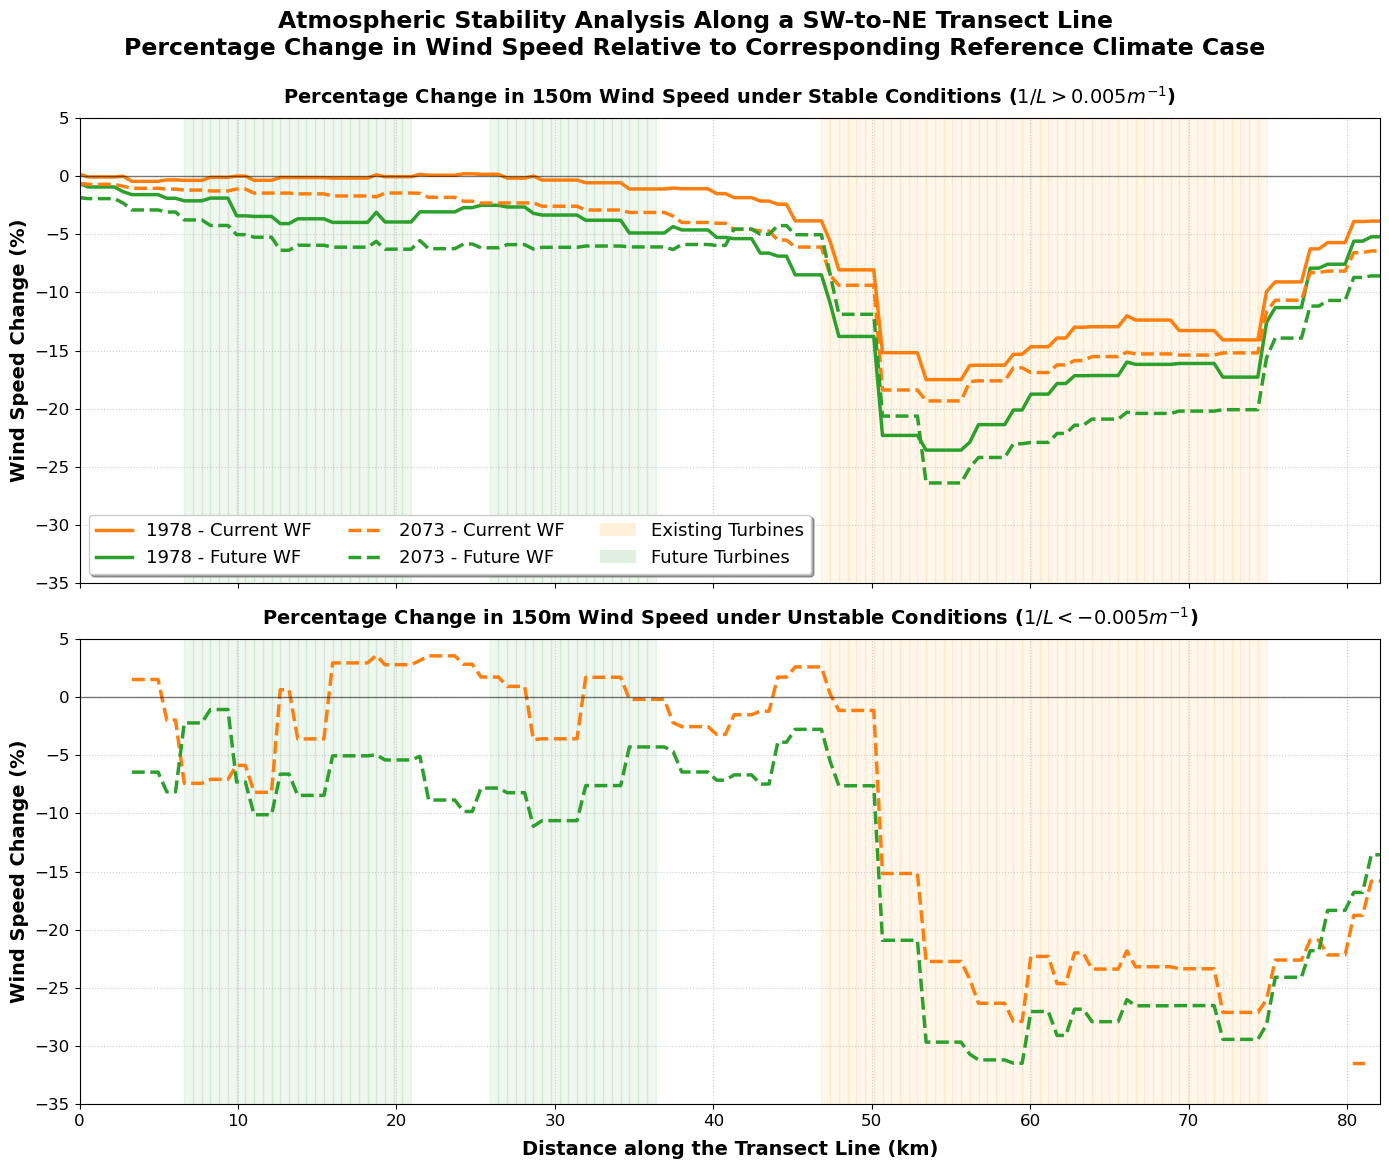

In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from shapely.geometry import Polygon, Point
from scipy.spatial import KDTree
from matplotlib.patches import Patch

# --- 1. Geometry & Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No WF', '#1f77b4', '-'),
    ('exp1994_WF', '1978 - Current WF', '#ff7f0e', '-'),
    ('exp1994_WFF', '1978 - Future WF', '#2ca02c', '-'),
    ('experiment2', '2073 - No WF', '#1f77b4', '--'),
    ('exp2071_WF', '2073 - Current WF', '#ff7f0e', '--'),
    ('exp2071_WFF', '2073 - Future WF', '#2ca02c', '--')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# EXTENDED WAKE TRANSECT
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# --- 2. Load True Coordinate Layouts for Shading Determination ---
master_data = np.loadtxt('/data/nobackup/boland/exp2071_WFF/WRF/run/windturbines.txt')
current_data = np.loadtxt('/data/nobackup/boland/experiment2/WRF/run/windturbines.txt')

# Define strict geographical boundaries to filter exclusively for Belgian waters
BELGIAN_EEZ_POLY = Polygon([(2.20, 51.30), (2.40, 51.55), (2.90, 51.75), (3.35, 51.72), (3.15, 51.35)])

# Use the duplicate-filtering engine from the map script
DUPLICATE_THRESHOLD_DEG = 0.0032 
base_existing_coords = []
for lat, lon in zip(current_data[:, 0], current_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        if len(base_existing_coords) == 0:
            base_existing_coords.append([lat, lon])
        else:
            temp_tree = KDTree(base_existing_coords)
            distance, _ = temp_tree.query([lat, lon])
            if distance > DUPLICATE_THRESHOLD_DEG:
                base_existing_coords.append([lat, lon])

base_existing_coords = np.array(base_existing_coords)

# Isolate new/future coordinates
final_existing_lons = list(base_existing_coords[:, 1])
final_existing_lats = list(base_existing_coords[:, 0])
final_new_lons = []
final_new_lats = []

existing_tree = KDTree(base_existing_coords)
for lat, lon in zip(master_data[:, 0], master_data[:, 1]):
    if BELGIAN_EEZ_POLY.contains(Point(lon, lat)):
        distance, _ = existing_tree.query([lat, lon])
        if distance <= DUPLICATE_THRESHOLD_DEG:
            continue
        if lon < 2.68:  # West dividing line for PEZ
            if len(final_new_lons) > 0:
                new_tree = KDTree(np.column_stack((final_new_lats, final_new_lons)))
                dist_to_new, _ = new_tree.query([lat, lon])
                if dist_to_new <= DUPLICATE_THRESHOLD_DEG:
                    continue
            final_new_lons.append(lon)
            final_new_lats.append(lat)
        else:
            final_existing_lons.append(lon)
            final_existing_lats.append(lat)

# Build final Trees for profile cross-referencing
tree_existing = KDTree(np.column_stack((final_existing_lats, final_existing_lons)))
tree_new = KDTree(np.column_stack((final_new_lats, final_new_lons)))

# --- 3. Compute Transect Positions & Distances ---
first_file = sorted(glob.glob(f"{base_path}{experiments[0][0]}/{file_pattern}"))[0]
nc_ref = Dataset(first_file)

transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    x_idx, y_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Great circle distance calculation along transect path
d_lat = (transect_lats - START_LAT) * 111.0
d_lon = (transect_lons - START_LON) * 111.0 * np.cos(np.deg2rad(START_LAT))
distances_km = np.sqrt(d_lat**2 + d_lon**2)

# --- 4. Spatial Intersection Shading Masks ---
SHADING_RADIUS_DEG = 0.0225 

current_mask = []
future_mask = []
for lat, lon in zip(transect_lats, transect_lons):
    dist_ext, _ = tree_existing.query([lat, lon])
    dist_new, _ = tree_new.query([lat, lon])
    current_mask.append(dist_ext <= SHADING_RADIUS_DEG)
    future_mask.append(dist_new <= SHADING_RADIUS_DEG)

# --- 5. Hourly Processing & Point-by-Point Stability Stratification ---
kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# Dictionaries to hold separate stability profiles
stable_profiles = {}
unstable_profiles = {}

for folder, label, color, linestyle in experiments:
    all_jan_files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in all_jan_files if int(f.split('_')[-2].split('-')[-1]) <= 30]
    if not files: 
        continue
    
    print(f"Stratifying data point-by-point for: {label}...")
    
    # Track accumulated parameters independently for every distinct point index
    stable_wspd_sum = np.zeros(NUM_POINTS)
    stable_point_counts = np.zeros(NUM_POINTS)   # Denominator array for stable conditions
    
    unstable_wspd_sum = np.zeros(NUM_POINTS)
    unstable_point_counts = np.zeros(NUM_POINTS) # Denominator array for unstable conditions
    
    for f in files:
        nc = Dataset(f)
        
        # Pull 3D Wind parameters and interpolate to Hub Height (150m)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        wspd_3d = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd_3d, height, TARGET_HEIGHT, meta=False)
        
        # Pull Surface Variables for Hourly Stability Assessment
        ust = getvar(nc, "UST", timeidx=None, meta=False)
        hfx = getvar(nc, "HFX", timeidx=None, meta=False)
        th2 = getvar(nc, "TH2", timeidx=None, meta=False)
        
        # Safeguard dimension structures if processing a file containing 1 isolated timestep
        if wspd_150m.ndim == 2:
            wspd_150m = np.expand_dims(wspd_150m, axis=0)
            ust = np.expand_dims(ust, axis=0)
            hfx = np.expand_dims(hfx, axis=0)
            th2 = np.expand_dims(th2, axis=0)
            
        num_times = wspd_150m.shape[0]
        
        for t in range(num_times):
            wspd_t = wspd_150m[t, :, :]
            ust_t = ust[t, :, :]
            hfx_t = hfx[t, :, :]
            th2_t = th2[t, :, :]
            
            # Calculate 2D Inverse Obukhov Length (1/L) grid
            hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
            inv_L = (kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
            
            # Extract profiles exactly tracking along the specified nodes
            transect_wspd = np.array([wspd_t[y, x] for y, x in zip(y_indices, x_indices)])
            transect_inv_L = np.array([inv_L[y, x] for y, x in zip(y_indices, x_indices)])
            
            # --- THE POINT-BY-POINT ADJUSTMENT ---
            # Generate conditional boolean filters per node instead of calculating corridor averages
            stable_mask = transect_inv_L > 0.005
            unstable_mask = transect_inv_L < -0.005
            
            # Accumulate values exclusively into cells matching the criteria
            stable_wspd_sum[stable_mask] += transect_wspd[stable_mask]
            stable_point_counts[stable_mask] += 1
            
            unstable_wspd_sum[unstable_mask] += transect_wspd[unstable_mask]
            unstable_point_counts[unstable_mask] += 1
                
        nc.close()
        
    # Element-by-element division using NaN fills for coordinates that never hit the thresholds
    with np.errstate(divide='ignore', invalid='ignore'):
        stable_profiles[folder] = np.where(stable_point_counts > 0, stable_wspd_sum / stable_point_counts, np.nan)
        unstable_profiles[folder] = np.where(unstable_point_counts > 0, unstable_wspd_sum / unstable_point_counts, np.nan)

# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Map baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-35, 5)  
    ax.tick_params(labelsize=12)

# Specific Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

ax1.legend(handles=stable_line_handles + zone_handles, loc='lower left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes_jan.png", dpi=300)
plt.show()

/tmp/ipykernel_398733/2377216836.py:55: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_398733/2377216836.py:56: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
/tmp/ipykernel_398733/2377216836.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
/tmp/ipykernel_398733/2377216836.py:59: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')


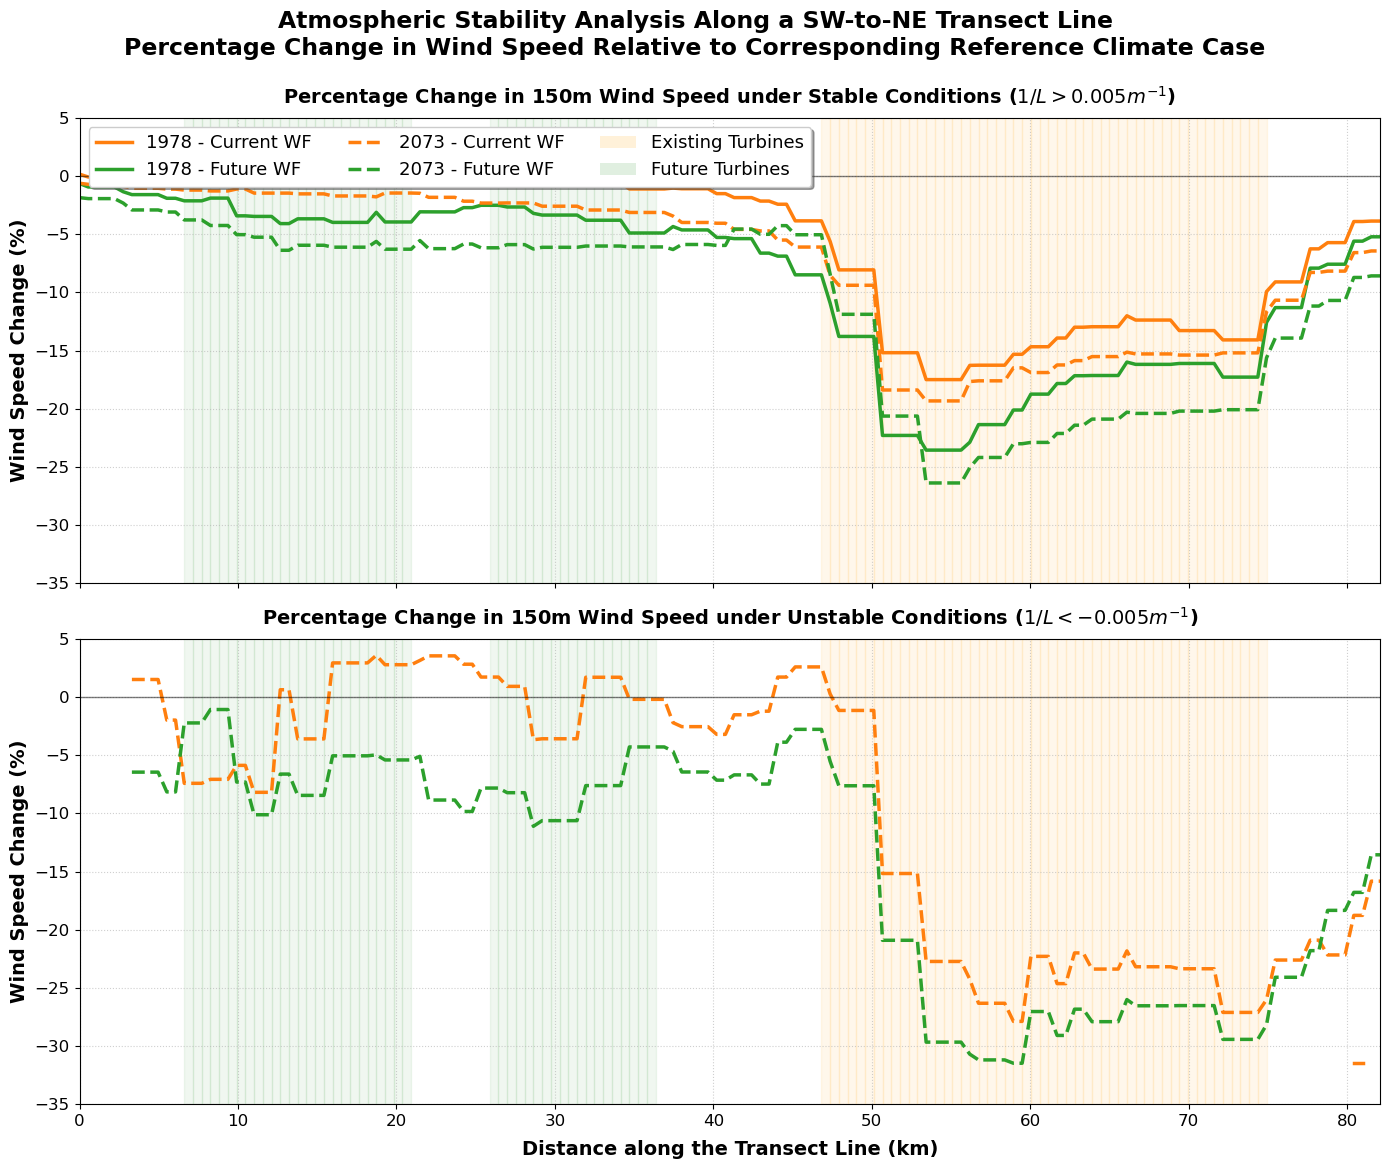

In [6]:
# --- 6. Plotting Two Panels ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

zone_handles = [
    Patch(facecolor='orange', alpha=0.15, label='Existing Turbines'),
    Patch(facecolor='green', alpha=0.12, label='Future Turbines')
]

stable_line_handles = []

# Map baseline references
stable_ref_1994 = stable_profiles.get('exp1994')
stable_ref_2071 = stable_profiles.get('experiment2')
unstable_ref_1994 = unstable_profiles.get('exp1994')
unstable_ref_2071 = unstable_profiles.get('experiment2')

for folder, label, color, linestyle in experiments:
    if folder in ['exp1994', 'experiment2']:
        continue
        
    # 1. Top Panel: STABLE WAKES
    if folder in stable_profiles:
        st_ref = stable_ref_1994 if '1994' in folder else stable_ref_2071
        if st_ref is not None:
            stable_diff = ((stable_profiles[folder] - st_ref) / st_ref) * 100
            line, = ax1.plot(distances_km, stable_diff, label=label, color=color, linestyle=linestyle, linewidth=2.5)
            stable_line_handles.append(line)
            
    # 2. Bottom Panel: UNSTABLE WAKES
    if folder in unstable_profiles:
        unst_ref = unstable_ref_1994 if '1994' in folder else unstable_ref_2071
        if unst_ref is not None:
            unstable_diff = ((unstable_profiles[folder] - unst_ref) / unst_ref) * 100
            ax2.plot(distances_km, unstable_diff, color=color, linestyle=linestyle, linewidth=2.5)

# Style & Format BOTH panels dynamically
for ax in [ax1, ax2]:
    ax.axhline(0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    ax.set_ylabel("Wind Speed Change (%)", fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(0, max(distances_km))
    ax.set_ylim(-35, 5)  
    ax.tick_params(labelsize=12)

# Specific Panel Annotations
ax1.set_title("Percentage Change in 150m Wind Speed under Stable Conditions ($1/L > 0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_title("Percentage Change in 150m Wind Speed under Unstable Conditions ($1/L < -0.005 m^{-1}$)", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Distance along the Transect Line (km)", fontsize=14, fontweight='bold', labelpad=8)

ax1.legend(handles=stable_line_handles + zone_handles, loc='upper left', fontsize=13, frameon=True, ncol=3, shadow=True, facecolor='white')

# --- 7. Dynamic Shading Implementation ---
for i in range(len(distances_km) - 1):
    if future_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='green', alpha=0.06, edgecolor='none')
    if current_mask[i]:
        ax1.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')
        ax2.axvspan(distances_km[i], distances_km[i+1], color='orange', alpha=0.08, edgecolor='none')

plt.suptitle("Atmospheric Stability Analysis Along a SW-to-NE Transect Line\n"
             "Percentage Change in Wind Speed Relative to Corresponding Reference Climate Case", fontsize=17, fontweight='bold', y=0.97)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig(f"{base_path}transect_stability_stratified_wakes_jan.png", dpi=300)
plt.show()

Extracting wind vectors point-by-point at Midpoint Index 75 (Grid X: 35, Y: 87)...


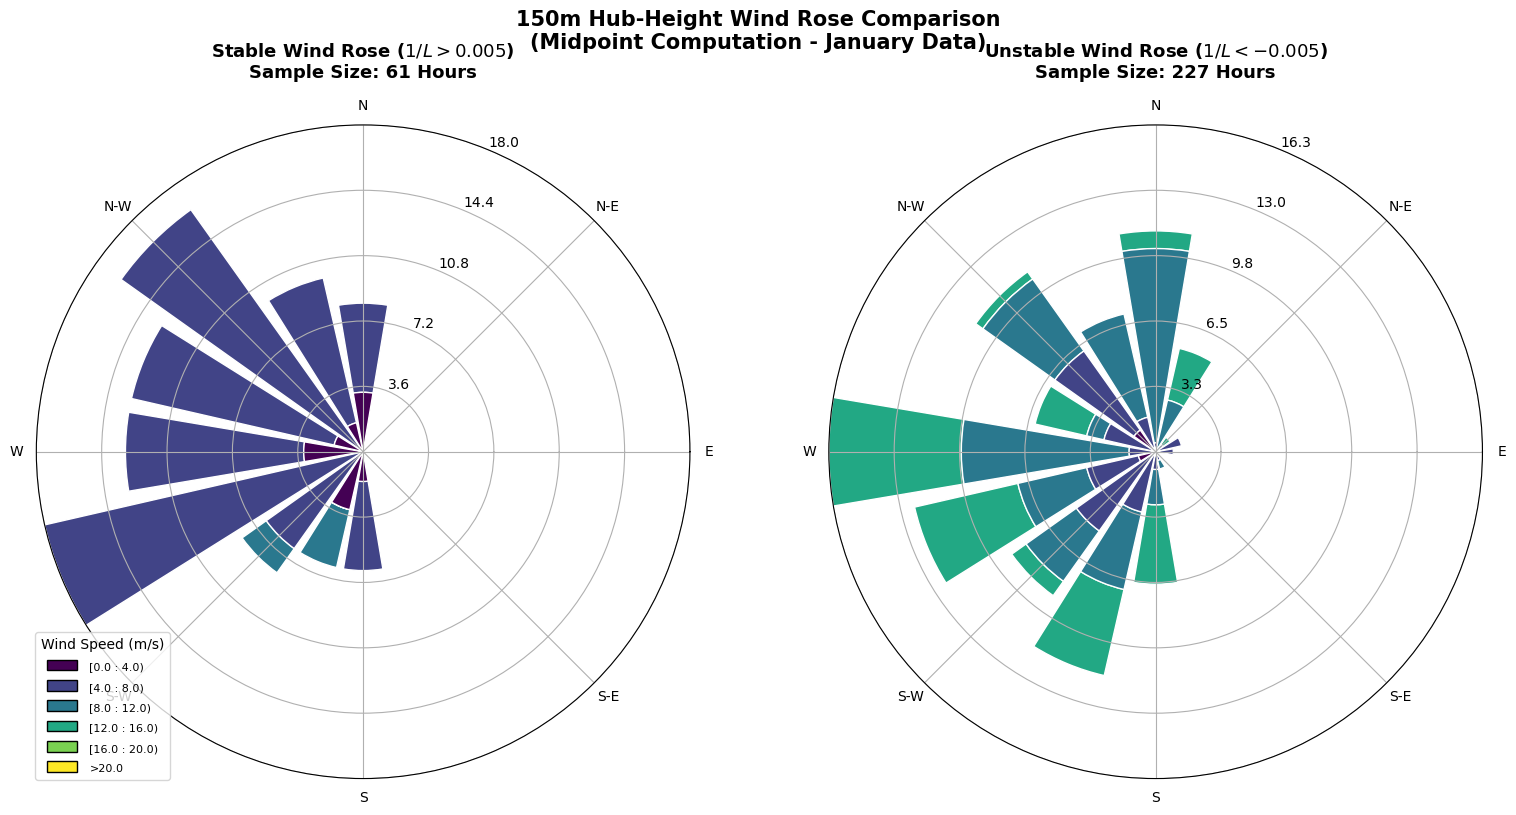

In [7]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from windrose import WindroseAxes
import matplotlib.cm as cm

# --- 1. Configuration & Target Selection ---
base_path = '/data/nobackup/boland/'
target_folder = 'exp1994_WFF'  
# UPDATED: Changed from '-08-' to '-01-' for January data consistency
file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# Define your transect line (exactly matching your main script)
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

# Exact spatial midpoint index matching your updated wake script
MID_INDEX = NUM_POINTS // 2

kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# --- 2. Build Grid Map ---
all_files = sorted(glob.glob(f"{base_path}{target_folder}/{file_pattern}"))
files = [f for f in all_files if int(f.split('_')[-2].split('-')[-1]) <= 30]

nc_ref = Dataset(files[0])
transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Isolate the precise grid coordinate for our midpoint anchor cell
mid_x = x_indices[MID_INDEX]
mid_y = y_indices[MID_INDEX]

# Arrays to gather historical data instances matching criteria at this point
stable_wspds = []
stable_wdirs = []
unstable_wspds = []
unstable_wdirs = []

# --- 3. Run Point-Specific Chronological Extraction ---
print(f"Extracting wind vectors point-by-point at Midpoint Index {MID_INDEX} (Grid X: {mid_x}, Y: {mid_y})...")

for f in files:
    nc = Dataset(f)
    
    u_3d = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
    v_3d = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
    height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
    
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    u_150m = interplevel(u_3d, height, TARGET_HEIGHT, meta=False)
    v_150m = interplevel(v_3d, height, TARGET_HEIGHT, meta=False)
    
    if u_150m.ndim == 2:
        u_150m = np.expand_dims(u_150m, axis=0)
        v_150m = np.expand_dims(v_150m, axis=0)
        ust = np.expand_dims(ust, axis=0)
        hfx = np.expand_dims(hfx, axis=0)
        th2 = np.expand_dims(th2, axis=0)
        
    num_times = u_150m.shape[0]
    
    for t in range(num_times):
        # Extract surface parameters strictly at our midpoint grid cell
        hfx_cell = hfx[t, mid_y, mid_x]
        ust_cell = ust[t, mid_y, mid_x]
        th2_cell = th2[t, mid_y, mid_x]
        
        # Calculate localized stability parameter
        hfx_safe = 1e-5 if hfx_cell == 0.0 else hfx_cell
        inv_L_cell = (kappa * g * hfx_safe) / (rho_cp * th2_cell * (ust_cell**3 + 1e-6))
        
        # Check if the localized cell meets the criteria for stable or unstable
        if inv_L_cell > 0.005 or inv_L_cell < -0.005:
            u_val = u_150m[t, mid_y, mid_x]
            v_val = v_150m[t, mid_y, mid_x]
            
            wspd = np.sqrt(u_val**2 + v_val**2)
            
            # Convert vectors to standard meteorological wind direction degrees (0 = North)
            wdir = np.degrees(np.arctan2(u_val, v_val)) + 180.0
            wdir = wdir % 360.0
            
            if inv_L_cell > 0.005:
                stable_wspds.append(wspd)
                stable_wdirs.append(wdir)
            else:
                unstable_wspds.append(wspd)
                unstable_wdirs.append(wdir)
                
    nc.close()

# --- 4. Plot Side-by-Side Normalized Wind Roses ---
fig = plt.figure(figsize=(16, 8))
speed_bins = np.arange(0, 24, 4) 

# Left Panel: Stable
ax1 = fig.add_subplot(121, projection="windrose")
if stable_wdirs:
    ax1.bar(stable_wdirs, stable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax1.set_title(f"Stable Wind Rose ($1/L > 0.005$)\nSample Size: {len(stable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
    # FIXED: Replaced legacy 'bbox_transform' parameter for reliable layout casting
    ax1.set_legend(loc='lower left', bbox_transform=fig.transFigure, title="Wind Speed (m/s)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Stable Hours at Midpoint", transform=ax1.transAxes, ha="center")

# Right Panel: Unstable
ax2 = fig.add_subplot(122, projection="windrose")
if unstable_wdirs:
    ax2.bar(unstable_wdirs, unstable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax2.set_title(f"Unstable Wind Rose ($1/L < -0.005$)\nSample Size: {len(unstable_wdirs)} Hours", fontsize=13, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "No Unstable Hours at Midpoint", transform=ax2.transAxes, ha="center")

plt.suptitle(f"150m Hub-Height Wind Rose Comparison\n"
             f"(Midpoint Computation - January Data)", 
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(f"{base_path}transect_midpoint_point_stratified_windroses_jan.png", dpi=300)
plt.show()

Extracting directional vectors across files...


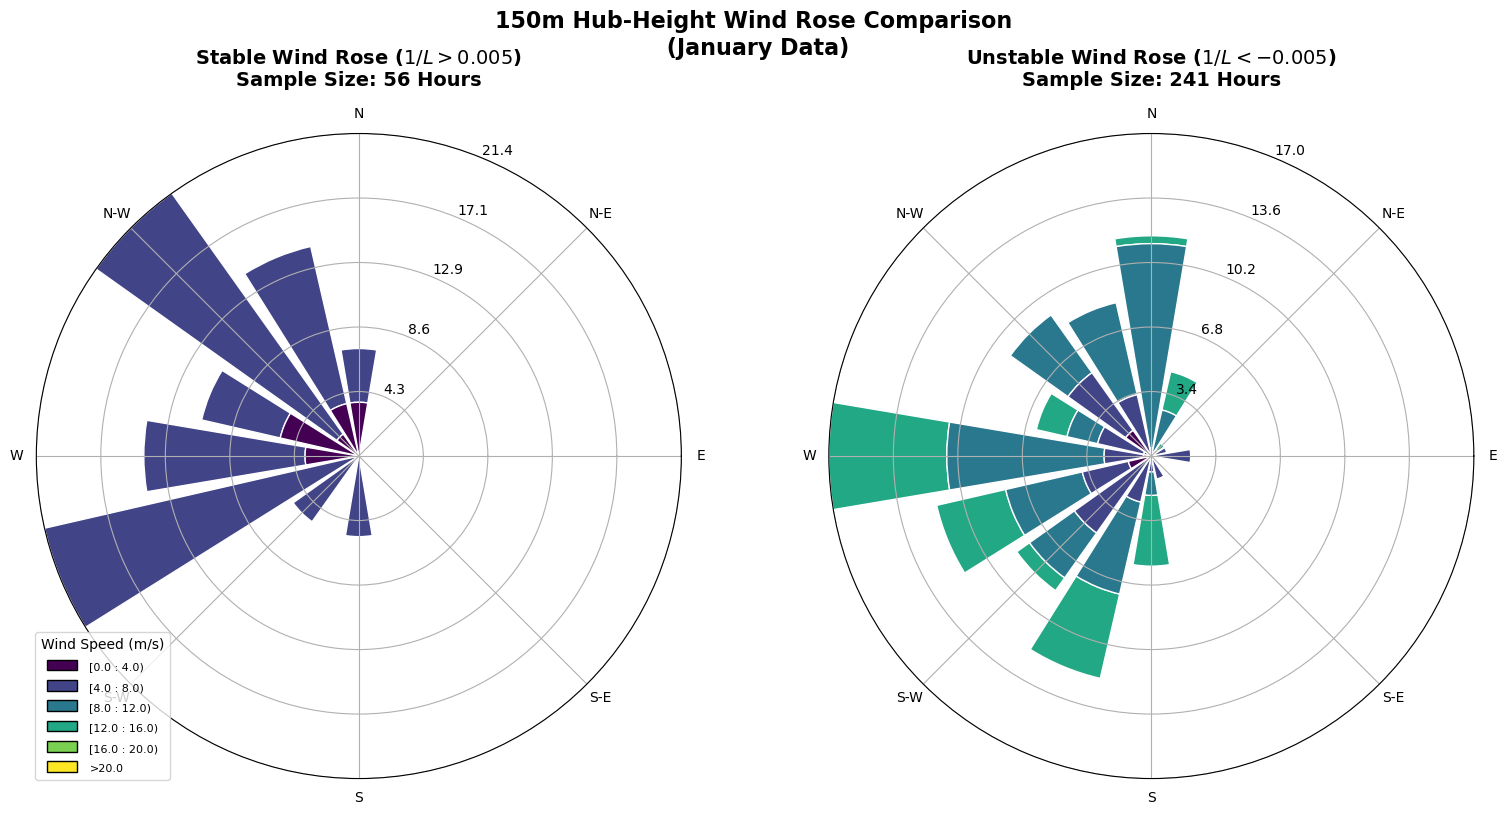

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from wrf import getvar, interplevel, ll_to_xy
from windrose import WindroseAxes
import matplotlib.cm as cm

# --- 1. Configuration & Geometry ---
base_path = '/data/nobackup/boland/'
# We typically pull the wind rose from a wake experiment to see the true operational layout
target_folder = 'exp1994_WFF'  
file_pattern = 'WRF/run/wrfout_d03_*-01-*'
TARGET_HEIGHT = 150.0

# Explicitly load your transect points to sample the local corridor wind climate
START_LAT, START_LON = 51.32, 2.30  
END_LAT, END_LON = 51.80, 3.20      
NUM_POINTS = 150                    

kappa = 0.40
g = 9.81
rho_cp = 1.225 * 1005.0

# --- 2. Build Transect Grid Indexes ---
all_files = sorted(glob.glob(f"{base_path}{target_folder}/{file_pattern}"))
files = [f for f in all_files if int(f.split('_')[-2].split('-')[-1]) <= 30]

nc_ref = Dataset(files[0])
transect_lats = np.linspace(START_LAT, END_LAT, NUM_POINTS)
transect_lons = np.linspace(START_LON, END_LON, NUM_POINTS)

x_indices, y_indices = [], []
for lat, lon in zip(transect_lats, transect_lons):
    y_idx, x_idx = ll_to_xy(nc_ref, lat, lon)
    x_indices.append(int(x_idx))
    y_indices.append(int(y_idx))
nc_ref.close()

# Lists to collect chronological hourly data instances
stable_wspds = []
stable_wdirs = []
unstable_wspds = []
unstable_wdirs = []

# --- 3. Extract and Regulate Stability-Stratified Vectors ---
print("Extracting directional vectors across files...")
for f in files:
    nc = Dataset(f)
    
    # Extract structural arrays safely using pure array structures
    u_3d = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
    v_3d = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
    height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
    
    # Extract Surface Stability Diagnostic Inputs
    ust = getvar(nc, "UST", timeidx=None, meta=False)
    hfx = getvar(nc, "HFX", timeidx=None, meta=False)
    th2 = getvar(nc, "TH2", timeidx=None, meta=False)
    
    # Handle both single-hour and multi-hour files smoothly
    u_150m = interplevel(u_3d, height, TARGET_HEIGHT, meta=False)
    v_150m = interplevel(v_3d, height, TARGET_HEIGHT, meta=False)
    if u_150m.ndim == 2:
        u_150m = np.expand_dims(u_150m, axis=0)
        v_150m = np.expand_dims(v_150m, axis=0)
        ust = np.expand_dims(ust, axis=0)
        hfx = np.expand_dims(hfx, axis=0)
        th2 = np.expand_dims(th2, axis=0)
        
    num_times = u_150m.shape[0]
    
    for t in range(num_times):
        hfx_t = hfx[t, :, :]
        ust_t = ust[t, :, :]
        th2_t = th2[t, :, :]
        
        # Calculate hourly stability fields across the grid
        hfx_safe = np.where(hfx_t == 0.0, 1e-5, hfx_t)
        inv_L = (kappa * g * hfx_safe) / (rho_cp * th2_t * (ust_t**3 + 1e-6))
        
        # Pull values exactly along the spatial track
        transect_inv_L = np.array([inv_L[y, x] for y, x in zip(y_indices, x_indices)])
        mean_corridor_inv_L = np.mean(transect_inv_L)
        
        # If the hour fits our stability criteria, compute the mean corridor wind direction
        if mean_corridor_inv_L > 0.005 or mean_corridor_inv_L < -0.005:
            u_t = u_150m[t, :, :]
            v_t = v_150m[t, :, :]
            
            # Sample vectors strictly across your transect corridor line
            transect_u = np.array([u_t[y, x] for y, x in zip(y_indices, x_indices)])
            transect_v = np.array([v_t[y, x] for y, x in zip(y_indices, x_indices)])
            
            # Calculate the overall mean wind components for this specific hour
            mean_u = np.mean(transect_u)
            mean_v = np.mean(transect_v)
            
            # Calculate absolute scalar wind speed magnitude
            wspd_scalar = np.sqrt(mean_u**2 + mean_v**2)
            
            # Convert wind vectors to meteorological degrees (0° = North, clockwise)
            wdir_deg = np.degrees(np.arctan2(mean_u, mean_v)) + 180.0
            wdir_deg = wdir_deg % 360.0
            
            # Append values to their respective binned arrays
            if mean_corridor_inv_L > 0.005:
                stable_wspds.append(wspd_scalar)
                stable_wdirs.append(wdir_deg)
            else:
                unstable_wspds.append(wspd_scalar)
                unstable_wdirs.append(wdir_deg)
                
    nc.close()

# --- 4. Plot Side-by-Side Binned Wind Roses ---
fig = plt.figure(figsize=(16, 8))

# Define matching, normalized wind speed bins for fair visual comparison
speed_bins = np.arange(0, 24, 4)

# Left Panel: Stable Regime Wind Rose
ax1 = fig.add_subplot(121, projection="windrose")
if len(stable_wdirs) > 0:
    ax1.bar(stable_wdirs, stable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax1.set_title(f"Stable Wind Rose ($1/L > 0.005$)\nSample Size: {len(stable_wdirs)} Hours", fontsize=14, fontweight='bold', pad=15)
    ax1.set_legend(loc='lower left', bbox_transform=fig.transFigure, title="Wind Speed (m/s)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "No Stable Hours Logged", transform=ax1.transAxes, ha="center")

# Right Panel: Unstable Regime Wind Rose
ax2 = fig.add_subplot(122, projection="windrose")
if len(unstable_wdirs) > 0:
    ax2.bar(unstable_wdirs, unstable_wspds, bins=speed_bins, normed=True, opening=0.85, edgecolor='white', cmap=cm.viridis)
    ax2.set_title(f"Unstable Wind Rose ($1/L < -0.005$)\nSample Size: {len(unstable_wdirs)} Hours", fontsize=14, fontweight='bold', pad=15)
else:
    ax2.text(0.5, 0.5, "No Unstable Hours Logged", transform=ax2.transAxes, ha="center")

plt.suptitle(f"150m Hub-Height Wind Rose Comparison\n (January Data)", 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(f"{base_path}transect_stability_stratified_windroses.png", dpi=300)
plt.show()

In [2]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- Configuration ---
base_path = '/data/nobackup/boland/'
experiments = [
    ('exp1994', '1978 - No wind farms'),
    ('exp1994_WF', '1978 - Current wind farms'),
    ('exp1994_WFF', '1978 - Future wind farms'),
    ('experiment2', '2073 - No wind farms'),
    ('exp2071_WF', '2073 - Current wind farms'),
    ('exp2071_WFF', '2073 - Future wind farms')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": ([51.58, 2.90, 51.53, 3.03], 0.325),
    "Belwind": ([51.72, 2.78, 51.65, 2.84], 0.165),
    "Northwind": ([51.63, 2.86, 51.58, 2.93], 0.216),
    "Nobelwind": ([51.73, 2.82, 51.68, 2.87], 0.165),
    "Rentel": ([51.62, 2.76, 51.56, 2.84], 0.309),
    "Norther": ([51.55, 3.00, 51.49, 3.08], 0.370),
    "SeaMade-Seastar": ([51.65, 2.71, 51.60, 2.77], 0.252),
    "SeaMade-Mermaid": ([51.74, 2.72, 51.69, 2.77], 0.260),
    "PEZ-Noordhinder Noord": ([51.54, 2.44, 51.46, 2.58], 0.700),
    "PEZ-Noordhinder Zuid": ([51.47, 2.46, 51.37, 2.62], 1.400),
    "PEZ-Fairy Bank": ([51.44, 2.63, 51.36, 2.76], 1.400)
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# Raw data storage for math operations
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}
raw_cf = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}

# --- Processing Loop ---
for folder, exp_name in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 30] # Keeping your 30-day index logic
    
    if not files:
        continue
    
    total_cf_accumulated = None
    total_hours = 0  

    for f in files:
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    mean_cf_grid = total_cf_accumulated / total_hours
    national_sum_gwh = 0.0

    for farm_name, (bbox, capacity_gw) in BELGIAN_INDIVIDUAL_FARMS.items():
        north, west, south, east = bbox
        spatial_mask = (lats >= south) & (lats <= north) & (lons >= west) & (lons <= east)
        
        if np.any(spatial_mask):
            farm_mean_cf = np.mean(mean_cf_grid[spatial_mask])
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            raw_cf[farm_name][exp_name] = farm_mean_cf
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            raw_cf[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
df_energy = pd.DataFrame(raw_energy)
df_cf = pd.DataFrame(raw_cf)

# --- Wake Deficit / Percentage Difference Analysis ---
wake_analysis_energy = {}
wake_analysis_cf = {}

# Define your evaluation pairs (Baseline vs Target Case)
analysis_pairs = [
    ('1978 - No wind farms', '1978 - Current wind farms', '1978 Current Wake Deficit (%)'),
    ('1978 - No wind farms', '1978 - Future wind farms', '1978 Future Wake Deficit (%)'),
    ('2073 - No wind farms', '2073 - Current wind farms', '2073 Current Wake Deficit (%)'),
    ('2073 - No wind farms', '2073 - Future wind farms', '2073 Future Wake Deficit (%)')
]

for baseline, case, column_name in analysis_pairs:
    # Formula: ((Case - Baseline) / Baseline) * 100
    pct_diff_energy = ((df_energy.loc[case] - df_energy.loc[baseline]) / df_energy.loc[baseline]) * 100
    wake_analysis_energy[column_name] = pct_diff_energy.round(2)
    
    # Note: National Total is omitted for CF since it's a farm-by-farm spatial metric
    pct_diff_cf = ((df_cf.loc[case] - df_cf.loc[baseline]) / df_cf.loc[baseline]) * 100
    wake_analysis_cf[column_name] = pct_diff_cf.round(2)

# Convert analysis dictionaries back to DataFrames
df_wake_energy = pd.DataFrame(wake_analysis_energy)
df_wake_cf = pd.DataFrame(wake_analysis_cf)

# --- Output Final Wake Effect Tables ---
print("\n" + "="*30 + " WAKE EFFECT ANALYSIS: ENERGY OUTPUT % CHANGE " + "="*30)
print("> Negative values indicate energy lost to cluster wake effects.")
print(df_wake_energy.to_markdown())

print("\n" + "="*30 + " WAKE EFFECT ANALYSIS: CAPACITY FACTOR % CHANGE " + "="*30)
print("> Represents the relative loss in turbine operational aerodynamic efficiency.")
print(df_wake_cf.to_markdown())


============================== WAKE EFFECT ANALYSIS: ENERGY OUTPUT % CHANGE ==============================
> Negative values indicate energy lost to cluster wake effects.
|                       |   1978 Current Wake Deficit (%) |   1978 Future Wake Deficit (%) |   2073 Current Wake Deficit (%) |   2073 Future Wake Deficit (%) |
|:----------------------|--------------------------------:|-------------------------------:|--------------------------------:|-------------------------------:|
| C-Power               |                          -22.09 |                         -31.79 |                          -17.81 |                         -26.86 |
| Belwind               |                          -18.33 |                         -29.68 |                          -17.12 |                         -27.7  |
| Northwind             |                          -22.25 |                         -33.37 |                          -20.1  |                         -30.23 |
| Nobelwind             |   

In [1]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel

# --- Configuration ---
base_path = '/data/nobackup/boland/'

experiments = [
    ('exp1994_WF', 'Current Farms - Current Climate'),
    ('exp1994_WFF', 'Future Farms - Current Climate'),
    ('exp2071_WF', 'Current Farms - Future Climate'),
    ('exp2071_WFF', 'Future Farms - Future Climate')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": ([51.58, 2.90, 51.53, 3.03], 0.325),
    "Belwind": ([51.72, 2.78, 51.65, 2.84], 0.165),
    "Northwind": ([51.63, 2.86, 51.58, 2.93], 0.216),
    "Nobelwind": ([51.73, 2.82, 51.68, 2.87], 0.165),
    "Rentel": ([51.62, 2.76, 51.56, 2.84], 0.309),
    "Norther": ([51.55, 3.00, 51.49, 3.08], 0.370),
    "SeaMade-Seastar": ([51.65, 2.71, 51.60, 2.77], 0.252),
    "SeaMade-Mermaid": ([51.74, 2.72, 51.69, 2.77], 0.260),
    "PEZ-Noordhinder Noord": ([51.54, 2.44, 51.46, 2.58], 0.700),
    "PEZ-Noordhinder Zuid": ([51.47, 2.46, 51.37, 2.62], 1.400),
    "PEZ-Fairy Bank": ([51.44, 2.63, 51.36, 2.76], 1.400)
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# Dictionary for raw total energy values
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}

# --- Processing Loop ---
for folder, exp_name in experiments:
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    # FIXED: Updated to <= 31 to include August 31st
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 31]
    
    if not files:
        print(f"Warning: No files found for {exp_name}")
        continue
    
    print(f"\nStarting extraction for: {exp_name} ({len(files)} files found)")
    
    total_cf_accumulated = None
    total_hours = 0  

    for i, f in enumerate(files, 1):
        print(f"   [{i}/{len(files)}] Processing file: {f.split('/')[-1]}", end='\r')
        
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    print(f"\n   Finished combining grids for {exp_name}.")
    mean_cf_grid = total_cf_accumulated / total_hours
    national_sum_gwh = 0.0

    for farm_name, (bbox, capacity_gw) in BELGIAN_INDIVIDUAL_FARMS.items():
        # DYNAMIC FILTER: Skip future PEZ zones if analyzing "Current Farms" scenarios
        if "Current Farms" in exp_name and farm_name.startswith("PEZ-"):
            raw_energy[farm_name][exp_name] = 0.0
            continue
            
        north, west, south, east = bbox
        spatial_mask = (lats >= south) & (lats <= north) & (lons >= west) & (lons <= east)
        
        if np.any(spatial_mask):
            farm_mean_cf = np.mean(mean_cf_grid[spatial_mask])
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
df_energy = pd.DataFrame(raw_energy).T

# --- Calculate Percentage Differences ---
if 'Future Farms - Current Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Expansion Impact (Current Climate) %'] = (
        (df_energy['Future Farms - Current Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Current Farms - Future Climate' in df_energy.columns:
    df_energy['Expansion Impact (Future Climate) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Current Farms - Future Climate']) 
        / df_energy['Current Farms - Future Climate']
    ) * 100

if 'Current Farms - Future Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Current Farms) %'] = (
        (df_energy['Current Farms - Future Climate'] - df_energy['Current Farms - Current Climate']) 
        / df_energy['Current Farms - Current Climate']
    ) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Future Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Future Farms) %'] = (
        (df_energy['Future Farms - Future Climate'] - df_energy['Future Farms - Current Climate']) 
        / df_energy['Future Farms - Current Climate']
    ) * 100

# --- Output Final Combined Table ---
print("\n" + "="*45 + " COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES " + "="*45)
print(df_energy.round(2).to_markdown())


Starting extraction for: Current Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Current Farms - Current Climate.

Starting extraction for: Future Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Future Farms - Current Climate.

Starting extraction for: Current Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2073-01-31_00:00:00
   Finished combining grids for Current Farms - Future Climate.

Starting extraction for: Future Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2073-01-31_00:00:00
   Finished combining grids for Future Farms - Future Climate.

============================================= COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES =============================================
|                       |   Current Farms - Current Climate |   Future F

In [2]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel
from scipy.interpolate import RegularGridInterpolator

# --- Configuration ---
base_path = '/data/nobackup/boland/'

experiments = [
    ('exp1994_WF', 'Current Farms - Current Climate'),
    ('exp1994_WFF', 'Future Farms - Current Climate'),
    ('exp2071_WF', 'Current Farms - Future Climate'),
    ('exp2071_WFF', 'Future Farms - Future Climate')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'

# Bounding boxes brought back ONLY to classify the raw nameless coordinates
BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": {
        "bbox": [51.58, 2.90, 51.53, 3.03], 
        "capacity_gw": 0.325
    },
    "Belwind": {
        "bbox": [51.72, 2.78, 51.65, 2.84], 
        "capacity_gw": 0.165
    },
    "Northwind": {
        "bbox": [51.63, 2.86, 51.58, 2.93], 
        "capacity_gw": 0.216
    },
    "Nobelwind": {
        "bbox": [51.73, 2.82, 51.68, 2.87], 
        "capacity_gw": 0.165
    },
    "Rentel": {
        "bbox": [51.62, 2.76, 51.56, 2.84], 
        "capacity_gw": 0.309
    },
    "Norther": {
        "bbox": [51.55, 3.00, 51.49, 3.08], 
        "capacity_gw": 0.370
    },
    "SeaMade-Seastar": {
        "bbox": [51.65, 2.71, 51.60, 2.77], 
        "capacity_gw": 0.252
    },
    "SeaMade-Mermaid": {
        "bbox": [51.74, 2.72, 51.69, 2.77], 
        "capacity_gw": 0.260
    },
    "PEZ-Noordhinder Noord": {
        "bbox": [51.54, 2.44, 51.46, 2.58], 
        "capacity_gw": 0.700
    },
    "PEZ-Noordhinder Zuid": {
        "bbox": [51.47, 2.46, 51.37, 2.62], 
        "capacity_gw": 1.400
    },
    "PEZ-Fairy Bank": {
        "bbox": [51.44, 2.63, 51.36, 2.76], 
        "capacity_gw": 1.400
    }
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

# --- Geographic Coordinate Sorter ---
def load_and_sort_turbines(filepath):
    turbines_by_farm = {farm: [] for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
    unassigned_count = 0
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    
                    # Check which farm bounding box this turbine falls into
                    assigned = False
                    for farm_name, info in BELGIAN_INDIVIDUAL_FARMS.items():
                        north, west, south, east = info["bbox"]
                        
                        # Match coordinate to bounding box
                        if (lat >= south) and (lat <= north) and (lon >= west) and (lon <= east):
                            turbines_by_farm[farm_name].append((lat, lon))
                            assigned = True
                            break
                    
                    if not assigned:
                        unassigned_count += 1
                except ValueError:
                    continue
                    
    if unassigned_count > 0:
        print(f"Notice: {unassigned_count} turbines in file fell outside all defined Belgian farm boxes.")
    return turbines_by_farm

# Load and sort coordinates using the bounding box geography checker
# turbine_layout = load_and_sort_turbines('windturbines.txt')

# Dictionary for raw total energy values
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}

# --- Processing Loop ---
for folder, exp_name in experiments:
    
    current_turbine_file = f"{base_path}{folder}/WRF/run/windturbines.txt" 
    
    print(f"\nLoading turbine layout from: {current_turbine_file}")
    turbine_layout = load_and_sort_turbines(current_turbine_file)
    
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 31]
    
    if not files:
        print(f"Warning: No files found for {exp_name}")
        continue
    
    print(f"\nStarting extraction for: {exp_name} ({len(files)} files found)")
    
    total_cf_accumulated = None
    total_hours = 0  

    for i, f in enumerate(files, 1):
        print(f"   [{i}/{len(files)}] Processing file: {f.split('/')[-1]}", end='\r')
        
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
            
        total_hours += hours_in_this_file
        nc.close()
        
    print(f"\n   Finished combining grids for {exp_name}.")
    mean_cf_grid = total_cf_accumulated / total_hours
    
    # --- Spatial Interpolation Setup ---
    lat_1d = lats[:, 0]
    lon_1d = lons[0, :]
    interp_cf = RegularGridInterpolator((lat_1d, lon_1d), mean_cf_grid, method='linear', bounds_error=False, fill_value=0.0)
    
    national_sum_gwh = 0.0

    for farm_name, info in BELGIAN_INDIVIDUAL_FARMS.items():
        capacity_gw = info["capacity_gw"]
        
        # DYNAMIC FILTER: Skip future PEZ zones if analyzing "Current Farms" scenarios
        if "Current Farms" in exp_name and farm_name.startswith("PEZ-"):
            raw_energy[farm_name][exp_name] = 0.0
            continue
            
        coords = turbine_layout.get(farm_name, [])
        
        if len(coords) > 0:
            # Extracts precise capacity factors at exact wake-affected coordinates
            turbine_cfs = interp_cf(coords)
            farm_mean_cf = np.mean(turbine_cfs)
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            national_sum_gwh += farm_energy_gwh
        else:
            raw_energy[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh

# --- Convert to DataFrames for easy vector math ---
df_energy = pd.DataFrame(raw_energy).T

# --- Calculate Percentage Differences ---
if 'Future Farms - Current Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Expansion Impact (Current Climate) %'] = ((df_energy['Future Farms - Current Climate'] - df_energy['Current Farms - Current Climate']) / df_energy['Current Farms - Current Climate']) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Current Farms - Future Climate' in df_energy.columns:
    df_energy['Expansion Impact (Future Climate) %'] = ((df_energy['Future Farms - Future Climate'] - df_energy['Current Farms - Future Climate']) / df_energy['Current Farms - Future Climate']) * 100

if 'Current Farms - Future Climate' in df_energy.columns and 'Current Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Current Farms) %'] = ((df_energy['Current Farms - Future Climate'] - df_energy['Current Farms - Current Climate']) / df_energy['Current Farms - Current Climate']) * 100

if 'Future Farms - Future Climate' in df_energy.columns and 'Future Farms - Current Climate' in df_energy.columns:
    df_energy['Climate Delta (Future Farms) %'] = ((df_energy['Future Farms - Future Climate'] - df_energy['Future Farms - Current Climate']) / df_energy['Future Farms - Current Climate']) * 100

# --- Output Final Combined Table ---
print("\n" + "="*45 + " COUPLING ANALYSIS: ENERGY & IMPACT PERCENTAGES " + "="*45)
print(df_energy.round(2).to_markdown())


Loading turbine layout from: /data/nobackup/boland/exp1994_WF/WRF/run/windturbines.txt
Notice: 1473 turbines in file fell outside all defined Belgian farm boxes.

Starting extraction for: Current Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Current Farms - Current Climate.

Loading turbine layout from: /data/nobackup/boland/exp1994_WFF/WRF/run/windturbines.txt
Notice: 7444 turbines in file fell outside all defined Belgian farm boxes.

Starting extraction for: Future Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Future Farms - Current Climate.

Loading turbine layout from: /data/nobackup/boland/exp2071_WF/WRF/run/windturbines.txt
Notice: 1473 turbines in file fell outside all defined Belgian farm boxes.

Starting extraction for: Current Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2

In [1]:
import glob
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from wrf import getvar, interplevel
from scipy.interpolate import RegularGridInterpolator

# --- Configuration ---
base_path = '/data/nobackup/boland/'

experiments = [
    ('exp1994_WF', 'Current Farms - Current Climate'),
    ('exp1994_WFF', 'Future Farms - Current Climate'),
    ('exp2071_WF', 'Current Farms - Future Climate'),
    ('exp2071_WFF', 'Future Farms - Future Climate')
]

file_pattern = 'WRF/run/wrfout_d03_*-01-*'

BELGIAN_INDIVIDUAL_FARMS = {
    "C-Power": {"bbox": [51.58, 2.90, 51.53, 3.03], "capacity_gw": 0.325},
    "Belwind": {"bbox": [51.72, 2.78, 51.65, 2.84], "capacity_gw": 0.165},
    "Northwind": {"bbox": [51.63, 2.86, 51.58, 2.93], "capacity_gw": 0.216},
    "Nobelwind": {"bbox": [51.73, 2.82, 51.68, 2.87], "capacity_gw": 0.165},
    "Rentel": {"bbox": [51.62, 2.76, 51.56, 2.84], "capacity_gw": 0.309},
    "Norther": {"bbox": [51.55, 3.00, 51.49, 3.08], "capacity_gw": 0.370},
    "SeaMade-Seastar": {"bbox": [51.65, 2.71, 51.60, 2.77], "capacity_gw": 0.252},
    "SeaMade-Mermaid": {"bbox": [51.74, 2.72, 51.69, 2.77], "capacity_gw": 0.260},
    "PEZ-Noordhinder Noord": {"bbox": [51.54, 2.44, 51.46, 2.58], "capacity_gw": 0.700},
    "PEZ-Noordhinder Zuid": {"bbox": [51.47, 2.46, 51.37, 2.62], "capacity_gw": 1.400},
    "PEZ-Fairy Bank": {"bbox": [51.44, 2.63, 51.36, 2.76], "capacity_gw": 1.400}
}

def wind_speed_to_capacity_factor(wspd):
    wspd_nodes = np.array([0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 11.5, 25.0, 99.0])
    power_nodes = np.array([0.0, 0.0, 0.53, 1.17, 2.15, 3.54, 5.43, 7.91, 11.07, 14.12, 15.00, 15.00, 0.0])
    computed_power_mw = np.interp(wspd, wspd_nodes, power_nodes)
    cf = computed_power_mw / 15.0
    cf = np.where(wspd > 25.0, 0.0, cf)
    return np.clip(cf, 0.0, 1.0)

def load_and_sort_turbines(filepath):
    turbines_by_farm = {farm: [] for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
    unassigned_count = 0
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat, lon = float(parts[0]), float(parts[1])
                    assigned = False
                    for farm_name, info in BELGIAN_INDIVIDUAL_FARMS.items():
                        north, west, south, east = info["bbox"]
                        if (lat >= south) and (lat <= north) and (lon >= west) and (lon <= east):
                            turbines_by_farm[farm_name].append((lat, lon))
                            assigned = True
                            break
                    if not assigned: unassigned_count += 1
                except ValueError: continue
    if unassigned_count > 0:
        print(f"Notice: {unassigned_count} turbines in file fell outside all defined Belgian farm boxes.")
    return turbines_by_farm

# Parallel tracking structures
raw_energy = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_energy["NATIONAL TOTAL (GWh)"] = {}

raw_cf = {farm: {} for farm in BELGIAN_INDIVIDUAL_FARMS.keys()}
raw_cf["NATIONAL AVERAGE (%)"] = {}

# --- Processing Loop ---
for folder, exp_name in experiments:
    current_turbine_file = f"{base_path}{folder}/WRF/run/windturbines.txt" 
    print(f"\nLoading turbine layout from: {current_turbine_file}")
    turbine_layout = load_and_sort_turbines(current_turbine_file)
    
    files = sorted(glob.glob(f"{base_path}{folder}/{file_pattern}"))
    files = [f for f in files if int(f.split('_')[-2].split('-')[-1]) <= 31]
    
    if not files:
        print(f"Warning: No files found for {exp_name}")
        continue
    
    print(f"Starting extraction for: {exp_name} ({len(files)} files found)")
    total_cf_accumulated = None
    total_hours = 0  

    for i, f in enumerate(files, 1):
        print(f"   [{i}/{len(files)}] Processing file: {f.split('/')[-1]}", end='\r')
        nc = Dataset(f)
        u = getvar(nc, "ua", timeidx=None, units="m s-1", meta=False)
        v = getvar(nc, "va", timeidx=None, units="m s-1", meta=False)
        height = getvar(nc, "height_agl", timeidx=None, units="m", meta=False)
        
        wspd = np.sqrt(u**2 + v**2)
        wspd_150m = interplevel(wspd, height, 150.0, meta=False)
        cf_snapshots = wind_speed_to_capacity_factor(wspd_150m)
        
        if cf_snapshots.ndim == 3:  
            hours_in_this_file = cf_snapshots.shape[0]
            cf_day_sum = np.sum(cf_snapshots, axis=0)
        else:  
            hours_in_this_file = 1
            cf_day_sum = cf_snapshots
            
        if total_cf_accumulated is None:
            total_cf_accumulated = cf_day_sum
            lats = getvar(nc, "XLAT", timeidx=0, meta=False)
            lons = getvar(nc, "XLONG", timeidx=0, meta=False)
        else:
            total_cf_accumulated += cf_day_sum
        total_hours += hours_in_this_file
        nc.close()
        
    print(f"\n   Finished combining grids for {exp_name}.")
    mean_cf_grid = total_cf_accumulated / total_hours
    
    lat_1d, lon_1d = lats[:, 0], lons[0, :]
    interp_cf = RegularGridInterpolator((lat_1d, lon_1d), mean_cf_grid, method='linear', bounds_error=False, fill_value=0.0)
    
    national_sum_gwh = 0.0
    national_active_capacity_gw = 0.0

    for farm_name, info in BELGIAN_INDIVIDUAL_FARMS.items():
        capacity_gw = info["capacity_gw"]
        
        if "Current Farms" in exp_name and farm_name.startswith("PEZ-"):
            raw_energy[farm_name][exp_name] = 0.0
            raw_cf[farm_name][exp_name] = 0.0
            continue
            
        coords = turbine_layout.get(farm_name, [])
        
        if len(coords) > 0:
            turbine_cfs = interp_cf(coords)
            farm_mean_cf = np.mean(turbine_cfs)
            farm_energy_gwh = farm_mean_cf * capacity_gw * total_hours
            
            raw_energy[farm_name][exp_name] = farm_energy_gwh
            raw_cf[farm_name][exp_name] = farm_mean_cf * 100.0  # Convert to percentage
            
            national_sum_gwh += farm_energy_gwh
            national_active_capacity_gw += capacity_gw
        else:
            raw_energy[farm_name][exp_name] = 0.0
            raw_cf[farm_name][exp_name] = 0.0
            
    raw_energy["NATIONAL TOTAL (GWh)"][exp_name] = national_sum_gwh
    # National CF calculated based on total energy produced vs maximum possible energy
    raw_cf["NATIONAL AVERAGE (%)"][exp_name] = (national_sum_gwh / (national_active_capacity_gw * total_hours)) * 100.0

# --- Process DataFrames and Vector Math ---
def calculate_deltas(df):
    if 'Future Farms - Current Climate' in df.columns and 'Current Farms - Current Climate' in df.columns:
        df['Expansion Impact (Current Climate) %'] = ((df['Future Farms - Current Climate'] - df['Current Farms - Current Climate']) / df['Current Farms - Current Climate']) * 100
    if 'Future Farms - Future Climate' in df.columns and 'Current Farms - Future Climate' in df.columns:
        df['Expansion Impact (Future Climate) %'] = ((df['Future Farms - Future Climate'] - df['Current Farms - Future Climate']) / df['Current Farms - Future Climate']) * 100
    if 'Current Farms - Future Climate' in df.columns and 'Current Farms - Current Climate' in df.columns:
        df['Climate Delta (Current Farms) %'] = ((df['Current Farms - Future Climate'] - df['Current Farms - Current Climate']) / df['Current Farms - Current Climate']) * 100
    if 'Future Farms - Future Climate' in df.columns and 'Future Farms - Current Climate' in df.columns:
        df['Climate Delta (Future Farms) %'] = ((df['Future Farms - Future Climate'] - df['Future Farms - Current Climate']) / df['Future Farms - Current Climate']) * 100
    return df

df_energy = calculate_deltas(pd.DataFrame(raw_energy).T)
df_cf = calculate_deltas(pd.DataFrame(raw_cf).T)

# --- Output Final Combined Tables ---
print("\n" + "="*40 + " TABLE 1: TOTAL ENERGY GENERATION (GWh) " + "="*40)
print(df_energy.round(2).to_markdown())

print("\n" + "="*40 + " TABLE 2: MEAN CAPACITY FACTORS (%) " + "="*40)
print(df_cf.round(2).to_markdown())


Loading turbine layout from: /data/nobackup/boland/exp1994_WF/WRF/run/windturbines.txt
Notice: 1473 turbines in file fell outside all defined Belgian farm boxes.
Starting extraction for: Current Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Current Farms - Current Climate.

Loading turbine layout from: /data/nobackup/boland/exp1994_WFF/WRF/run/windturbines.txt
Notice: 7444 turbines in file fell outside all defined Belgian farm boxes.
Starting extraction for: Future Farms - Current Climate (31 files found)
   [31/31] Processing file: wrfout_d03_1978-01-31_00:00:00
   Finished combining grids for Future Farms - Current Climate.

Loading turbine layout from: /data/nobackup/boland/exp2071_WF/WRF/run/windturbines.txt
Notice: 1473 turbines in file fell outside all defined Belgian farm boxes.
Starting extraction for: Current Farms - Future Climate (31 files found)
   [31/31] Processing file: wrfout_d03_2073